# 卓易信息投资价值分析报告

## 一.公司背景介绍

江苏卓易信息科技股份有限公司（股票代码：688258.SH）成立于2008年5月，总部位于江苏无锡，是软件和信息技术服务业领域的高新技术企业，专注于基础软件与云服务相关业务，在国产基础软件自主可控领域具有重要地位。

卓易信息形成“固件+云服务+IDE”三位一体核心格局。核心固件业务为服务器等设备提供BIOS/BMC产品，是国内唯一获英特尔x86架构授权的独立供应商，深度适配主流国产芯片与整机厂商；IDE业务聚焦AI赋能，推进自主可控产品商业化；云服务为政企客户提供端到端解决方案，在长三角市场树立标杆。公司技术壁垒显著，凭借多项专利与软件著作权，以持续研发投入保障领先性。

2008年成立后，逐步深耕基础软件领域；2016年引入英特尔资本等战略投资，强化技术与供应链协同；2019年12月成功登陆上交所科创板，完成IPO融资5.76亿元，开启资本化发展新阶段；近年来积极拥抱AI技术，加速IDE业务商业化进程，2025年筹划发行H股，推进“A+H”两地上市布局，助力国际市场拓展。

## 二.公司市场表现分析

### 1.股票价格获取

本报告通过Akshare库获取卓易信息2020年1约1日至2024年12约31日的股票交易数据，包括每个交易日的开盘价、收盘价、最高价、最低价、成交量和成交额。以下是获取股票数据的代码：

In [1]:
import pandas as pd
import numpy as np
import akshare as ak
import pdfplumber
import os
import re
from collections import Counter
import jieba
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

F:\Miniconda\envs\py311\Lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
stock_code = "688258"      
start_date = "20200101"
end_date = "20241231"

stock_code = "688258"  
hist_df = ak.stock_zh_a_hist(symbol=stock_code, period="daily", start_date=start_date, end_date=end_date)
print("历史数据列名:", hist_df.columns.tolist())
print("\n历史数据前5行:")
print(hist_df.head())

hist_df.to_csv('annual_reports/stock_data.csv', index=False, encoding='utf-8-sig')

历史数据列名: ['日期', '股票代码', '开盘', '收盘', '最高', '最低', '成交量', '成交额', '振幅', '涨跌幅', '涨跌额', '换手率']

历史数据前5行:
           日期    股票代码     开盘     收盘     最高     最低    成交量          成交额     振幅  \
0  2020-01-02  688258  86.23  85.61  87.50  84.22  18386  157828928.0   3.81   
1  2020-01-03  688258  83.50  80.00  84.79  79.47  27760  228270892.0   6.21   
2  2020-01-06  688258  77.76  78.88  83.58  77.60  21029  169585155.0   7.48   
3  2020-01-07  688258  77.20  87.21  89.20  77.20  35975  303246720.0  15.21   
4  2020-01-08  688258  85.97  84.53  86.82  82.10  22979  193471455.0   5.41   

     涨跌幅   涨跌额    换手率  
0  -0.64 -0.55   9.29  
1  -6.55 -5.61  14.03  
2  -1.40 -1.12  10.63  
3  10.56  8.33  18.19  
4  -3.07 -2.68  11.62  


In [3]:
price_clean = hist_df[["日期", "收盘"]].copy()

price_clean["日期"] = pd.to_datetime(price_clean["日期"])

price_clean = price_clean.sort_values("日期")

price_clean = price_clean.set_index("日期")

price_clean = price_clean.rename(columns={"收盘": "close"})

print(price_clean.head())
print(price_clean.tail())
print(price_clean.index.is_monotonic_increasing)
print(f"价格序列长度：{len(price_clean)}")

            close
日期               
2020-01-02  85.61
2020-01-03  80.00
2020-01-06  78.88
2020-01-07  87.21
2020-01-08  84.53
            close
日期               
2024-12-25  35.45
2024-12-26  36.47
2024-12-27  35.50
2024-12-30  35.18
2024-12-31  34.60
True
价格序列长度：1212


### 2.股票收益和波动计算

本报告计算了股票的对数收益和波动率，并做可视化处理，代码如下：

In [13]:
final_df = price_clean.copy().sort_index()

final_df["log_ret"] = np.log(final_df["close"]).diff()

final_df.head()

,close,log_ret
日期,,
2020-01-02,85.61,NaN
2020-01-03,80.00,-0.067775
2020-01-06,78.88,-0.014099
2020-01-07,87.21,0.100391
2020-01-08,84.53,-0.031213


In [14]:
window = 20
trading_days = 252

window = 20

final_df["volatility"] = (
    final_df["log_ret"]
    .rolling(window)
    .std()
    * np.sqrt(trading_days)
)

final_df.head(25)

,close,log_ret,volatility
日期,,,
2020-01-02,85.61,NaN,NaN
2020-01-03,80.00,-0.067775,NaN
2020-01-06,78.88,-0.014099,NaN
2020-01-07,87.21,0.100391,NaN
2020-01-08,84.53,-0.031213,NaN
2020-01-09,94.00,0.106188,NaN
2020-01-10,92.20,-0.019335,NaN
2020-01-13,94.00,0.019335,NaN
2020-01-14,88.65,-0.058599,NaN


In [15]:
threshold = final_df["volatility"].quantile(0.8)
final_df["high_vol"] = final_df["volatility"] > threshold

final_df.head(30)

,close,log_ret,volatility,high_vol
日期,,,,
2020-01-02,85.61,NaN,NaN,False
2020-01-03,80.00,-0.067775,NaN,False
2020-01-06,78.88,-0.014099,NaN,False
2020-01-07,87.21,0.100391,NaN,False
2020-01-08,84.53,-0.031213,NaN,False
2020-01-09,94.00,0.106188,NaN,False
2020-01-10,92.20,-0.019335,NaN,False
2020-01-13,94.00,0.019335,NaN,False
2020-01-14,88.65,-0.058599,NaN,False


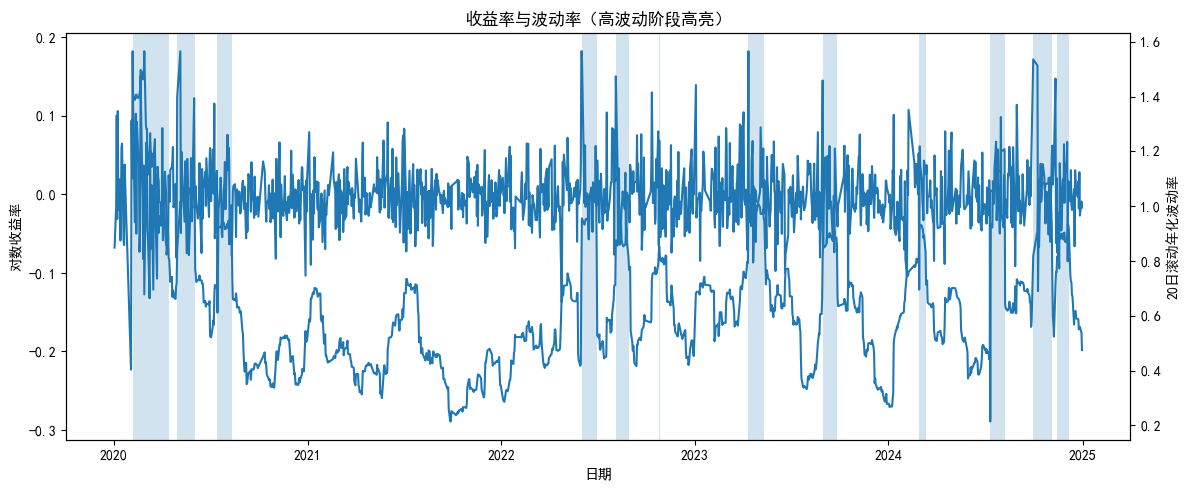

In [16]:
df = final_df.copy()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df.index, df["log_ret"])
ax1.set_xlabel("日期")
ax1.set_ylabel("对数收益率")

ax2 = ax1.twinx()
ax2.plot(df.index, df["volatility"])
ax2.set_ylabel("20日滚动年化波动率")

ax1.fill_between(
    df.index, 0, 1,
    where=df["high_vol"],
    transform=ax1.get_xaxis_transform(),
    alpha=0.2
)

ax1.set_title("收益率与波动率（高波动阶段高亮）")
plt.tight_layout()
plt.show()

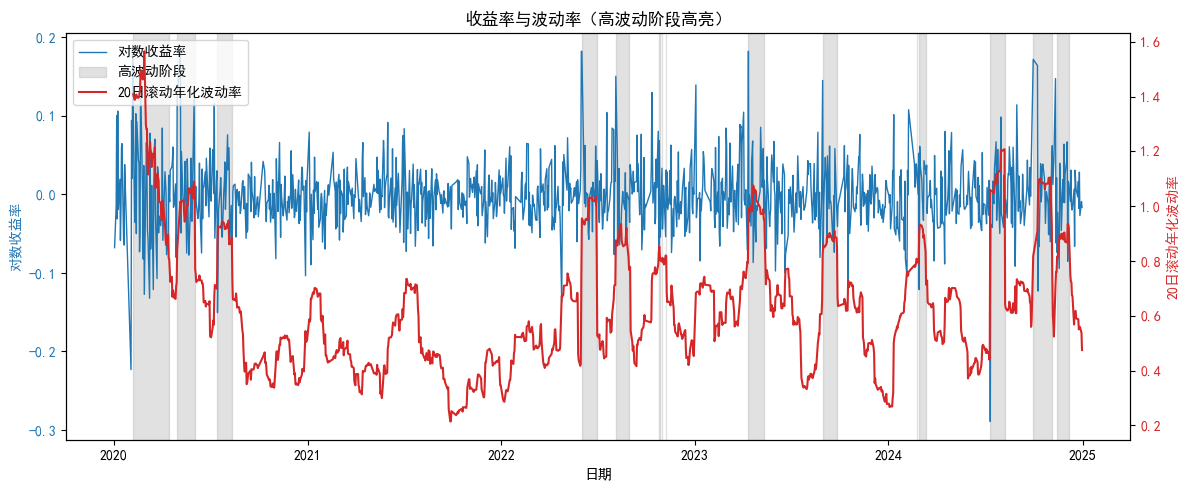

In [17]:
df = final_df.copy()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    df.index,
    df["log_ret"],
    label="对数收益率",
    linewidth=1,
    color="tab:blue"
)
ax1.set_xlabel("日期")
ax1.set_ylabel("对数收益率", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(
    df.index,
    df["volatility"],
    label="20日滚动年化波动率",
    linewidth=1.5,
    color="tab:red"
)
ax2.set_ylabel("20日滚动年化波动率", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.fill_between(
    df.index,
    0, 1,
    where=df["high_vol"],
    transform=ax1.get_xaxis_transform(),
    color="darkgray",
    alpha=0.35,
    label="高波动阶段"
)

ax1.set_title("收益率与波动率（高波动阶段高亮）")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper left"
)

plt.tight_layout()
plt.show()

### 3.分析

（1）波动特征：高波动阶段与市场/公司事件强关联  
图表中灰色高波动阶段（如2020年初、2022-2023年多次区间），对应：  
2020 年初：市场受疫情冲击整体波动，叠加公司上市初期（2019年上市）的新股情绪波动；  
2022-2024年：信创板块政策/行业周期波动、公司股东减持（2024年公告）、净利润大幅下滑（2024年归母净利润降41.52%）等事件，直接推高了波动率（红色曲线明显抬升）。

（2）收益率与波动率的联动性  
高波动阶段：蓝色对数收益率的涨跌幅度显著放大（如2020年初、2024年部分区间），说明股价短期涨跌剧烈，与波动率（红色曲线）的抬升高度同步；  
低波动阶段：收益率波动收窄（如2021年），对应公司业务相对平稳、市场情绪温和的时期。

（3）背后的驱动因素    
业绩波动：2024年营收微增但净利润大降（因投资收益减少）、扣非净利润虽增长但市场更关注归母净利润，导致股价情绪性波动；  
业务与行业：作为华为生态+信创标的，行业政策（如国产化节奏）、华为合作进展的变化，会放大股价波动；  
股东行为：2024年员工持股平台减持，直接加剧了短期波动率。  
整体来看，卓易信息的股价波动既受行业周期、公司业绩/事件的影响，也体现了 “小市值 + 题材属性” 股票的典型特征：波动率高、收益与事件/情绪绑定性强。

## 三.公司财务绩效分析

### 1.资产负债表获取及分析

资产负债表获取代码如下：

In [4]:
report_dates = ["20201231", "20211231", "20221231", "20231231", "20241231"]

In [5]:
balance_list = []

for date in report_dates:
    df_all = ak.stock_zcfz_em(date=date)

    df_one = df_all[df_all["股票代码"] == stock_code].copy()

    df_one["报告期"] = date

    balance_list.append(df_one)

balance_df = pd.concat(balance_list, ignore_index=True)

print("资产负债表前5行：")
print(balance_df.head())

print("\n资产负债表字段名：")
print(balance_df.columns)

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

资产负债表前5行：
     序号    股票代码  股票简称       资产-货币资金       资产-应收账款        资产-存货        资产-总资产  \
0  2134  688258  卓易信息  2.088683e+08  1.536968e+08  13514180.25  1.006316e+09   
1  3304  688258  卓易信息  3.623084e+08  1.513978e+08  21611319.95  1.132696e+09   
2  3297  688258  卓易信息  3.691911e+08  2.203494e+08  30061965.79  1.199814e+09   
3  3405  688258  卓易信息  4.130765e+08  2.112835e+08   9244046.68  1.639653e+09   
4  4592  688258  卓易信息  2.892490e+08  2.243292e+08   9067759.75  1.552080e+09   

    资产-总资产同比      负债-应付账款     负债-预收账款        负债-总负债    负债-总负债同比      资产负债率  \
0   6.636327  20854288.77         NaN  1.042060e+08   18.463454  10.355201   
1  12.558715  18994545.70   331676.10  2.269428e+08  117.782743  20.035624   
2   5.925474  19833316.63  1529233.59  2.230450e+08   -1.717538  18.589962   
3  36.658910  29271352.01   929801.47  4.440935e+08   99.104940  27.084609   
4  -5.340910  41065459.67  1089560.10  7.004342e+08   57.722227  45.128734   

         股东权益合计        公告日期       报告期  


In [6]:
balance_df.to_csv("annual_reports/balance_5y.csv",index=False,encoding="utf-8-sig")
print("资产负债表已保存：annual_reports/balance_5y.csv")

资产负债表已保存：annual_reports/balance_5y.csv


从 “资产结构、负债变化、偿债能力” 三个维度分析其财务特征：

（1）资产结构：货币资金充裕，但总资产波动与业务/融资有关  
货币资金：2020-2023年持续增长（从2.09亿→4.13亿），2024年回落至2.89亿（但仍较充裕），说明公司现金流储备较强；  
总资产：2023年同比大增36.66%（对应公司业务扩张/融资），2024年同比降5.34%（或因资产处置/业绩收缩），与2023-2024 年股价的“冲高后回落”形成对应。

（2）负债变化：2024年负债激增，驱动因素是应付账款+预收账款  
总负债：2021年同比增长117.78%、2023年增长99.1%、2024年增长57.72%，负债扩张速度远快于资产；  
负债结构：2024年应付账款从2.93亿增至4.11亿，预收账款从93万增至109万，说明公司供应链占款增加+订单预收款微增，但负债扩张更多是被动性（应付账款）。

（3）偿债能力：资产负债率飙升，2024年风险显著抬升  
资产负债率：从2020年的10.36%（低负债），一路升至2024年的45.13%，尤其是2024年单年从27.08%跳涨至45.13%，说明偿债压力大幅增加；  
股东权益：2024年从11.96亿降至8.52亿，是资产负债率飙升的核心原因（股东权益缩水+负债扩张），这也与2024年股价下跌、股东减持的市场表现形成联动。

### 2.利润表获取及分析

利润表获取代码如下：

In [7]:
income_list = []

for date in report_dates:
    df_all = ak.stock_lrb_em(date=date)
    df_all["股票代码"] = df_all["股票代码"].astype(str)

    df_one = df_all[df_all["股票代码"] == stock_code].copy()
    df_one["报告期"] = date
    income_list.append(df_one)

income_df = pd.concat(income_list, ignore_index=True)

print("利润表前5行：")
print(income_df.head())
print("\n利润表字段名：")
print(income_df.columns)

income_df.to_csv("annual_reports/income_lrb_5y.csv", index=False, encoding="utf-8-sig")
print("\n已保存：annual_reports/income_lrb_5y.csv")

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

利润表前5行：
     序号    股票代码  股票简称          净利润  净利润同比         营业总收入    营业总收入同比  \
0  2130  688258  卓易信息  58053310.21  41.34  1.984163e+08  -6.773975   
1  3300  688258  卓易信息  42148495.57 -27.40  2.366041e+08  19.246334   
2  3291  688258  卓易信息  51005019.83  21.01  2.820228e+08  19.196043   
3  3403  688258  卓易信息  56160479.96  10.11  3.202238e+08  13.545389   
4  3403  688258  卓易信息  32841483.65 -41.52  3.233926e+08   0.989558   

     营业总支出-营业支出  营业总支出-销售费用   营业总支出-管理费用  营业总支出-财务费用   营业总支出-营业总支出  \
0  8.188321e+07  5074084.46  23748140.72 -2881478.72  1.486592e+08   
1  1.116281e+08  5264212.81  29639963.19   508264.23  2.031786e+08   
2  1.378840e+08  9955637.65  39039576.11 -1114599.19  2.812510e+08   
3  1.724220e+08  7216698.07  63140841.31  4180339.59  3.165156e+08   
4  1.545882e+08  9050086.01  52845920.87  7353748.25  3.084383e+08   

          营业利润         利润总额        公告日期       报告期  
0  63730776.72  63850147.55  2022-04-27  20201231  
1  43762851.82  43489397.48  2023-04-20  20211

分析业绩与市场表现的联动逻辑：

（1）营收与利润的变化  
营业总收入：2020-2023年持续增长（从1.98亿→3.20亿），2024年仅微增0.99%（增长陷入停滞）；  
净利润：2020-2023年呈 “增长→下滑→回升” 的波动趋势，但2024年同比大降41.52%（从5.62亿→3.28亿），是业绩的明显拐点。

（2）成本费用的变化  
营业总支出：2020-2023年随营收扩张同步增长，但2024年营收微增的情况下，营业总支出从3.17亿降至3.08 亿（成本端略有收缩，但未对冲利润下滑）；  
费用端：2024年销售费用、管理费用、财务费用均同比增加（尤其是财务费用从 418万→735万），反映出费用刚性+财务成本上升，进一步挤压了利润。

（3）业绩与股价/波动率的关联  
2020-2023年：营收利润的波动（2021年净利润下降27.4%、2022-2023年回升），对应股价的区间震荡+阶段性行情，波动率随业绩预期变化而起伏；  
2024年：营收停滞+净利润大降，叠加之前资产负债率飙升、股东减持的财务/股东层面压力，直接导致股价下跌、收益率负向波动放大、波动率抬升——业绩恶化是 2024年股价与市场情绪走弱的核心基本面原因。

### 3.现金流量表的获取与分析

现金流量表获取代码如下：

In [8]:
cashflow_list = []

for date in report_dates:
    df_all = ak.stock_xjll_em(date=date)  # 全市场现金流量表（该报告期）
    df_all["股票代码"] = df_all["股票代码"].astype(str)

    df_one = df_all[df_all["股票代码"] == stock_code].copy()
    df_one["报告期"] = date
    cashflow_list.append(df_one)

cashflow_df = pd.concat(cashflow_list, ignore_index=True)

print("现金流量表前5行：")
print(cashflow_df.head())
print("\n现金流量表字段名：")
print(cashflow_df.columns)

cashflow_df.to_csv("annual_reports/cashflow_xjll_5y.csv", index=False, encoding="utf-8-sig")
print("\n已保存：annual_reports/cashflow_xjll_5y.csv")

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

现金流量表前5行：
     序号    股票代码  股票简称     净现金流-净现金流   净现金流-同比增长  经营性现金流-现金流量净额  经营性现金流-净现金流占比  \
0  2118  688258  卓易信息 -9.712638e+07 -138.507841   9.291241e+07      95.661349   
1  3292  688258  卓易信息  1.534381e+08  257.977761   5.243463e+07      34.173149   
2  3289  688258  卓易信息  5.136645e+06  -96.652301  -1.896696e+06     -36.924807   
3  3401  688258  卓易信息  4.650671e+07  805.390877   1.139847e+08     245.093080   
4  3402  688258  卓易信息 -1.237428e+08 -366.075209   9.603139e+07      77.605618   

   投资性现金流-现金流量净额  投资性现金流-净现金流占比  融资性现金流-现金流量净额  融资性现金流-净现金流占比        公告日期  \
0  -1.680030e+08    -172.973620  -2.193817e+07     -22.587240  2022-04-27   
1   3.436151e+07      22.394379   6.666640e+07      43.448403  2023-04-20   
2   2.040481e+07     397.240051  -1.323556e+07    -257.669367  2024-04-19   
3  -1.810251e+08    -389.245139   1.139118e+08     244.936193  2025-04-18   
4  -5.985436e+07     -48.369965  -1.608428e+08    -129.981508  2025-04-18   

        报告期  
0  20201231  
1  20211231 

现金流核心特征：净额波动剧烈，结构稳定性弱

（1）净现金流：年度间大幅震荡，2024年转负且创阶段性新低  
2020年净现金流为-9712.64万元，2021年大幅转正至1.53亿元（同比增长 258%），2022年骤降至513.66万元（同比下滑 96.65%），2023年回升至4650.67万元（同比增长805.39%），2024年再次转负至-1.24亿元（同比下滑366.08%）。这种剧烈波动反映公司现金流受经营、投资、融资活动的综合影响极强，整体现金流安全垫的稳定性不足。

（2）经营性现金流：现金创造能力相对稳健，但2022年短暂转负  
2020/2021/2023/2024年经营性现金流净额均为正，2022年为-189.67万元，是唯一的负现金流年份。2023年经营性现金流净额达1.14亿元，占当年净现金流的245.09%，是支撑当年净现金流转正的核心力量；2024年经营性现金流净额为9603.14万元，占净现金流的 77.61%，说明经营活动仍在创造现金，但不足以覆盖投资与融资端的现金流出。

（3）投资性现金流：持续大额净流出，2023年流出规模达峰值  
除2021年投资性现金流净额为正（3436.15万元）外，其余年份均为净流出，2023年流出规模最大（-1.81亿元），2024年流出收窄至-5985.44万元。投资性现金流的持续净流出，反映公司在2020-2024年期间持续进行固定资产投资、对外投资或资产处置等资本运作，2023年的大额流出或与业务扩张相关。

（4）融资性现金流：与投资、经营现金流形成“对冲”，2024年大额净流出  
2020/2021年融资性现金流净额分别为-2193.82万元、6666.64万元，2022/2023年持续为正，2024年转为-1.61亿元，是当年净现金流转负的核心驱动因素。融资性现金流的“收放”与公司资金缺口高度相关，2024年的大额净流出或与偿还债务、股东分红、回购股份等行为有关。

### 4.综合分析

将三张表的关键指标按年汇总到一张“年度财务指标表”，代码如下：

In [18]:
balance = pd.read_csv("annual_reports/balance_5y.csv")
income  = pd.read_csv("annual_reports/income_lrb_5y.csv")
cashflow = pd.read_csv("annual_reports/cashflow_xjll_5y.csv")

def add_year(df):
    df = df.copy()
    df["year"] = df["报告期"].astype(str).str[:4].astype(int)
    return df

balance = add_year(balance)
income = add_year(income)
cashflow = add_year(cashflow)

bal = balance[["year", "资产-总资产", "负债-总负债", "资产负债率", "股东权益合计"]].copy()
inc = income[["year", "营业总收入", "净利润", "营业利润", "利润总额"]].copy()
cf  = cashflow[["year", "经营性现金流-现金流量净额", "投资性现金流-现金流量净额", "融资性现金流-现金流量净额", "净现金流-净现金流"]].copy()

fin = bal.merge(inc, on="year", how="inner").merge(cf, on="year", how="inner")
fin = fin.sort_values("year").reset_index(drop=True)

fin["净利率"] = fin["净利润"] / fin["营业总收入"]
fin["经营现金流/净利润"] = fin["经营性现金流-现金流量净额"] / fin["净利润"]

cols_to_yoy = [
    "营业总收入", "净利润", "资产-总资产", "负债-总负债",
    "经营性现金流-现金流量净额", "投资性现金流-现金流量净额",
    "净利率", "资产负债率"
]
for c in cols_to_yoy:
    fin[c + "_YoY"] = fin[c].pct_change()

print("年度财务指标表（核心列）预览：")
show_cols = ["year",
             "营业总收入","净利润","净利率",
             "资产-总资产","负债-总负债","资产负债率",
             "经营性现金流-现金流量净额","投资性现金流-现金流量净额",
             "经营现金流/净利润"]
print(fin[show_cols])

年度财务指标表（核心列）预览：
   year         营业总收入          净利润       净利率        资产-总资产        负债-总负债  \
0  2020  1.984163e+08  58053310.21  0.292583  1.006316e+09  1.042060e+08   
1  2021  2.366041e+08  42148495.57  0.178139  1.132696e+09  2.269428e+08   
2  2022  2.820228e+08  51005019.83  0.180854  1.199814e+09  2.230450e+08   
3  2023  3.202238e+08  56160479.96  0.175379  1.639653e+09  4.440935e+08   
4  2024  3.233926e+08  32841483.65  0.101553  1.552080e+09  7.004342e+08   

       资产负债率  经营性现金流-现金流量净额  投资性现金流-现金流量净额  经营现金流/净利润  
0  10.355201   9.291241e+07  -1.680030e+08   1.600467  
1  20.035624   5.243463e+07   3.436151e+07   1.244045  
2  18.589962  -1.896696e+06   2.040481e+07  -0.037186  
3  27.084609   1.139847e+08  -1.810251e+08   2.029625  
4  45.128734   9.603139e+07  -5.985436e+07   2.924088  


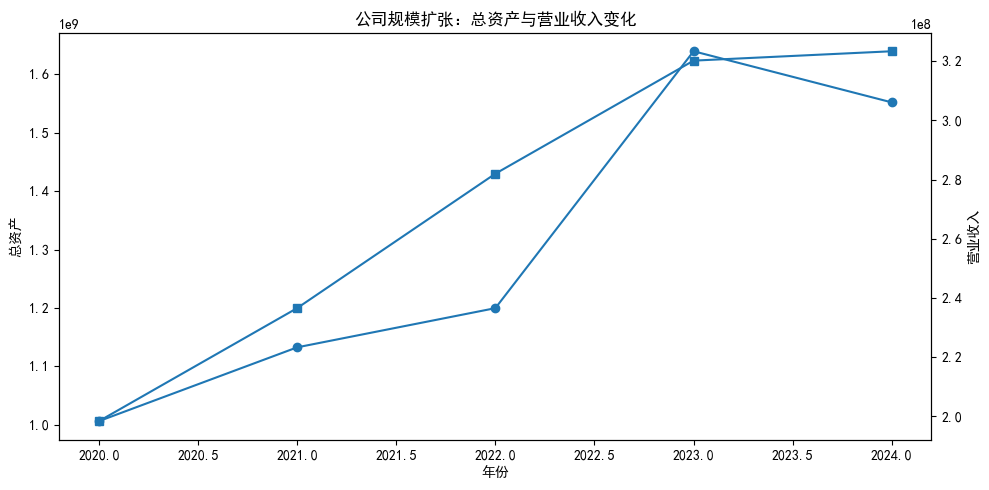

In [19]:
df = fin.copy()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df["year"], df["资产-总资产"], marker="o")
ax1.set_xlabel("年份")
ax1.set_ylabel("总资产")

ax2 = ax1.twinx()
ax2.plot(df["year"], df["营业总收入"], marker="s")
ax2.set_ylabel("营业收入")

ax1.set_title("公司规模扩张：总资产与营业收入变化")
plt.tight_layout()
plt.show()

总资产2020-2023年持续攀升，2023年后小幅回调，体现公司阶段性完成资本布局后进入资产优化阶段；

营业收入与总资产扩张节奏高度契合，2023年后仍稳步上升，说明资产投入对主业营收的支撑作用持续有效。

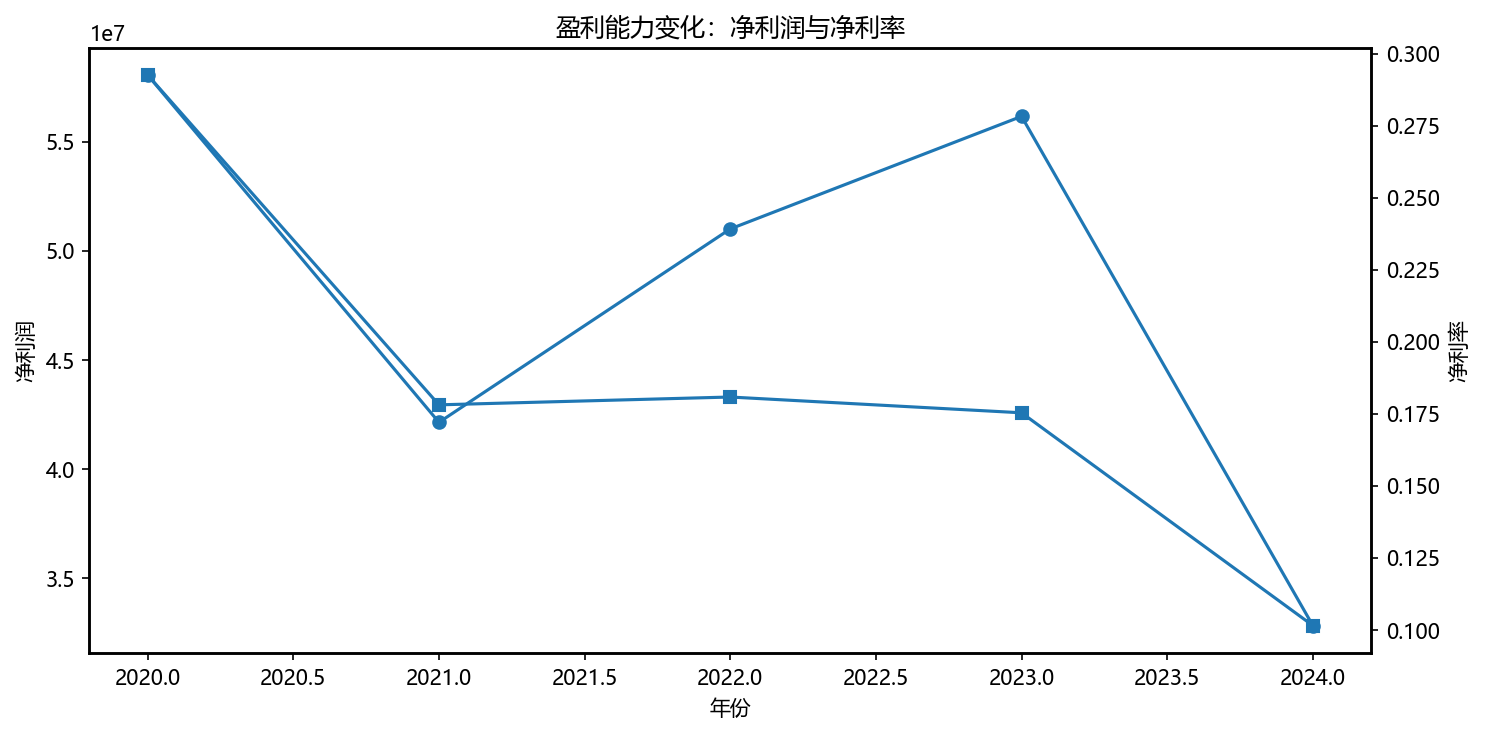

In [22]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df["year"], df["净利润"], marker="o")
ax1.set_xlabel("年份")
ax1.set_ylabel("净利润")

ax2 = ax1.twinx()
ax2.plot(df["year"], df["净利率"], marker="s")
ax2.set_ylabel("净利率")

ax1.set_title("盈利能力变化：净利润与净利率")
plt.tight_layout()
plt.show()

净利率先骤降后修复再回落，2023年后大幅收缩，反映成本管控或产品溢价能力受外部环境冲击明显，盈利稳定性不足；

净利润在2021年后长期维持低位，与前期资产、收入扩张的节奏脱节，显示规模增长未有效转化为盈利提升。

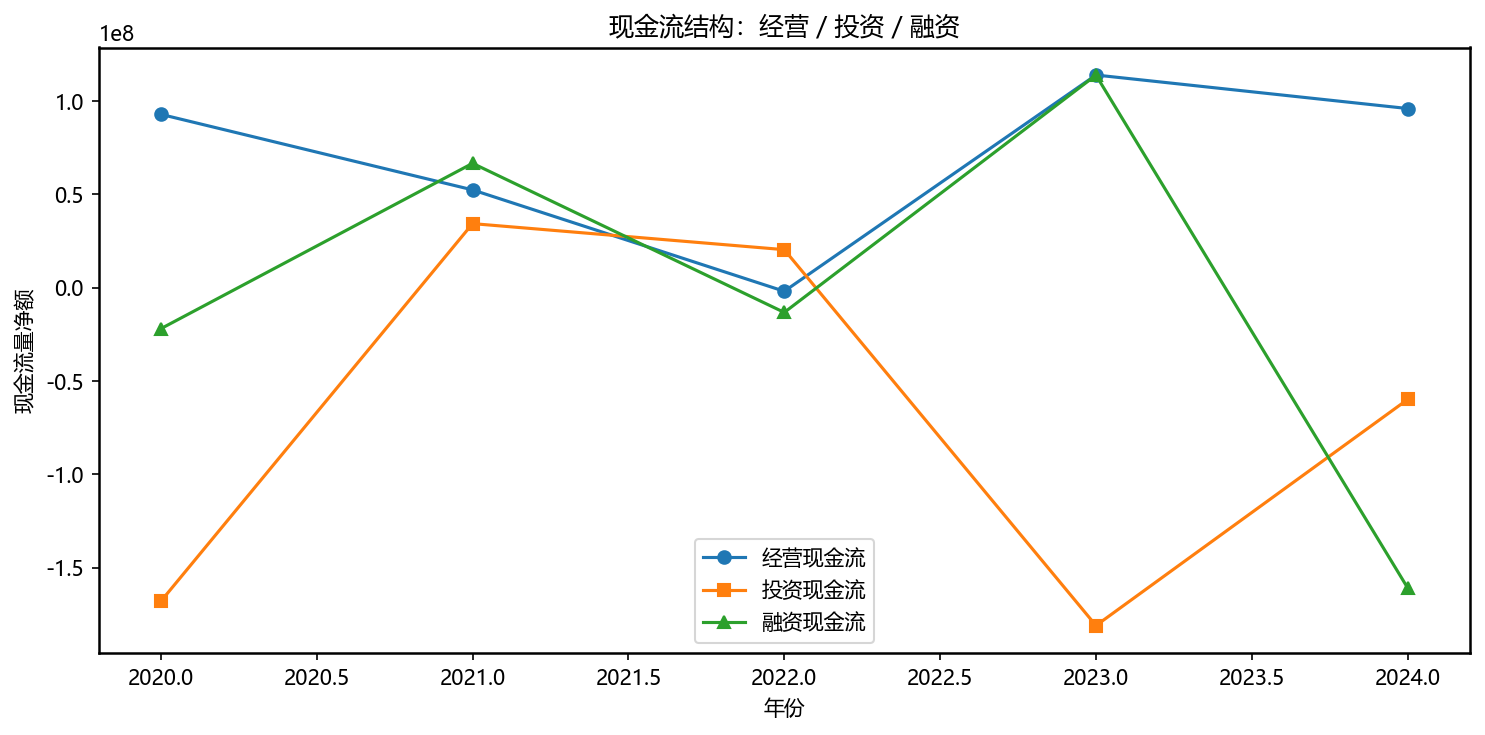

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(df["year"], df["经营性现金流-现金流量净额"], marker="o")
plt.plot(df["year"], df["投资性现金流-现金流量净额"], marker="s")
plt.plot(df["year"], df["融资性现金流-现金流量净额"], marker="^")

plt.xlabel("年份")
plt.ylabel("现金流量净额")
plt.title("现金流结构：经营 / 投资 / 融资")
plt.legend(["经营现金流", "投资现金流", "融资现金流"])

plt.tight_layout()
plt.show()

经营现金流先稳后升，2023年后流入规模扩大，反映主业现金创造能力阶段性增强，但前期波动明显；

投资现金流持续净流出，且2023年流出幅度显著扩大，体现公司长期维持资本性投入，扩张节奏未放缓；

融资现金流在2021、2023年大幅流入，2024年转为流出，说明外部融资是支撑投资的重要补充，但资金供给稳定性不足。

## 四.宏观数据获取及分析

### 1.GDP、CPI数据获取

GDP、CPI数据获取代码如下：

In [9]:
gdp = ak.macro_china_gdp()

print(gdp.columns)

print(gdp.head())

Index(['季度', '国内生产总值-绝对值', '国内生产总值-同比增长', '第一产业-绝对值', '第一产业-同比增长', '第二产业-绝对值',
       '第二产业-同比增长', '第三产业-绝对值', '第三产业-同比增长'],
      dtype='object')
            季度  国内生产总值-绝对值  国内生产总值-同比增长  第一产业-绝对值  第一产业-同比增长  第二产业-绝对值  \
0  2025年第1-3季度   1015036.1          5.2   58060.8        3.8  364020.0   
1  2025年第1-2季度    660535.8          5.3   31171.8        3.7  239050.2   
2    2025年第1季度    318758.0          5.4   11712.8        3.5  111902.9   
3  2024年第1-4季度   1349083.5          5.0   91413.9        3.5  492087.1   
4  2024年第1-3季度    975357.4          4.8   57363.6        3.4  356492.0   

   第二产业-同比增长  第三产业-绝对值  第三产业-同比增长  
0        4.9  592955.2        5.4  
1        5.3  390313.8        5.5  
2        5.9  195142.3        5.3  
3        5.3  765582.5        5.0  
4        5.4  561501.8        4.7  


In [10]:
gdp_a = gdp.copy()

gdp_a["date"] = gdp_a["季度"].astype(str)

gdp_a["date"] = gdp_a["date"].str.replace("年第1季度",  "-03-31", regex=False)
gdp_a["date"] = gdp_a["date"].str.replace("年第1-2季度", "-06-30", regex=False)
gdp_a["date"] = gdp_a["date"].str.replace("年第1-3季度", "-09-30", regex=False)
gdp_a["date"] = gdp_a["date"].str.replace("年第1-4季度", "-12-31", regex=False)

gdp_a["date"] = pd.to_datetime(gdp_a["date"])

gdp_a = gdp_a.rename(columns={
    "国内生产总值-绝对值": "GDP",
    "国内生产总值-同比增长": "GDPrate"
})

gdp_a = gdp_a[["date", "GDP", "GDPrate"]].sort_values("date").reset_index(drop=True)

gdp_a.to_csv(
    "annual_reports/macro_gdp_2020_2024.csv",
    index=False,
    encoding="utf-8-sig"
)

print(gdp_a.head())
print(gdp_a.tail())

        date       GDP  GDPrate
0 2006-03-31   47831.7     12.4
1 2006-06-30  101247.0     13.1
2 2006-09-30  158067.6     12.7
3 2006-12-31  222578.4     12.7
4 2007-03-31   58080.6     13.6
         date        GDP  GDPrate
74 2024-09-30   975357.4      4.8
75 2024-12-31  1349083.5      5.0
76 2025-03-31   318758.0      5.4
77 2025-06-30   660535.8      5.3
78 2025-09-30  1015036.1      5.2


In [11]:
cpi = ak.macro_china_cpi()

print(cpi.columns)

print(cpi.head())

Index(['月份', '全国-当月', '全国-同比增长', '全国-环比增长', '全国-累计', '城市-当月', '城市-同比增长',
       '城市-环比增长', '城市-累计', '农村-当月', '农村-同比增长', '农村-环比增长', '农村-累计'],
      dtype='object')
          月份  全国-当月  全国-同比增长  全国-环比增长  全国-累计  城市-当月  城市-同比增长  城市-环比增长  城市-累计  \
0  2025年11月份  100.7      0.7     -0.1  100.0  100.7      0.7     -0.1  100.0   
1  2025年10月份  100.2      0.2      0.2   99.9  100.3      0.3      0.2  100.0   
2  2025年09月份   99.7     -0.3      0.1   99.9   99.8     -0.2      0.0   99.9   
3  2025年08月份   99.6     -0.4      0.0   99.9   99.7     -0.3      0.0  100.0   
4  2025年07月份  100.0      0.0      0.4   99.9  100.0      0.0      0.4  100.0   

   农村-当月  农村-同比增长  农村-环比增长  农村-累计  
0  100.4      0.4      0.0   99.7  
1   99.8     -0.2      0.1   99.7  
2   99.5     -0.5      0.2   99.7  
3   99.4     -0.6      0.1   99.7  
4   99.7     -0.3      0.3   99.7  


In [12]:
cpi["date"] = (
    cpi["月份"]
    .astype(str)
    .str.replace("年", "-", regex=False)
    .str.replace("月份", "-01", regex=False)
)

cpi["date"] = pd.to_datetime(cpi["date"])

cpi_simple = cpi.rename(columns={
    "全国-同比增长": "CPIrate"
})

cpi_simple = cpi_simple[["date", "CPIrate"]].sort_values("date")

cpi_5y = cpi_simple[
    (cpi_simple["date"] >= "2020-01-01") &
    (cpi_simple["date"] <= "2024-12-31")
]

cpi_5y.to_csv(
    "annual_reports/macro_cpi_2020_2024.csv",
    index=False,
    encoding="utf-8-sig"
)

print("CPI（全国同比，2020–2024）已保存")
print(cpi_5y.head())

CPI（全国同比，2020–2024）已保存
         date  CPIrate
70 2020-01-01      5.4
69 2020-02-01      5.2
68 2020-03-01      4.3
67 2020-04-01      3.3
66 2020-05-01      2.4


### 2.将股票数据、财务数据、及宏观数据统一对齐到“年度频率”

In [24]:
df_stock = final_df.copy()
df_stock["year"] = df_stock.index.year

stock_year = df_stock.groupby("year").agg(
    avg_ret=("log_ret", "mean"),
    avg_vol=("volatility", "mean"),
    high_vol_ratio=("high_vol", "mean")
).reset_index()

print(stock_year)

   year   avg_ret   avg_vol  high_vol_ratio
0  2020 -0.001784  0.747838        0.362140
1  2021 -0.001872  0.458058        0.000000
2  2022  0.000611  0.613578        0.177686
3  2023  0.000789  0.638668        0.165289
4  2024 -0.001480  0.704643        0.280992


In [25]:
gdp_year = gdp_a.copy()
gdp_year["year"] = gdp_year["date"].dt.year

gdp_year = (
    gdp_year
    .sort_values("date")
    .groupby("year")
    .tail(1)
    .reset_index(drop=True)
)

gdp_5y = gdp_year[
    (gdp_year["year"] >= 2020) &
    (gdp_year["year"] <= 2024)
].copy()

print(gdp_5y)

         date        GDP  GDPrate  year
14 2020-12-31  1034867.6      2.3  2020
15 2021-12-31  1173823.0      8.6  2021
16 2022-12-31  1234029.4      3.1  2022
17 2023-12-31  1294271.7      5.4  2023
18 2024-12-31  1349083.5      5.0  2024


In [26]:
cpi_year = cpi_5y.copy()
cpi_year["year"] = cpi_year["date"].dt.year

cpi_year = (
    cpi_year
    .groupby("year")["CPIrate"]
    .mean()
    .reset_index()
)

print(cpi_year)

   year   CPIrate
0  2020  2.508333
1  2021  0.916667
2  2022  1.958333
3  2023  0.241667
4  2024  0.241667


In [27]:
final_panel = fin.copy()

final_panel = final_panel.merge(stock_year, on="year", how="left")

final_panel = final_panel.merge(gdp_year, on="year", how="left")

final_panel = final_panel.merge(cpi_year, on="year", how="left")

print("最终对齐后的分析主表：")
print(final_panel)

最终对齐后的分析主表：
   year        资产-总资产        负债-总负债      资产负债率        股东权益合计         营业总收入  \
0  2020  1.006316e+09  1.042060e+08  10.355201  9.021100e+08  1.984163e+08   
1  2021  1.132696e+09  2.269428e+08  20.035624  9.057536e+08  2.366041e+08   
2  2022  1.199814e+09  2.230450e+08  18.589962  9.767690e+08  2.820228e+08   
3  2023  1.639653e+09  4.440935e+08  27.084609  1.195559e+09  3.202238e+08   
4  2024  1.552080e+09  7.004342e+08  45.128734  8.516461e+08  3.233926e+08   

           净利润         营业利润         利润总额  经营性现金流-现金流量净额  ...  \
0  58053310.21  63730776.72  63850147.55   9.291241e+07  ...   
1  42148495.57  43762851.82  43489397.48   5.243463e+07  ...   
2  51005019.83  47581035.21  46600014.46  -1.896696e+06  ...   
3  56160479.96  55928322.67  56009776.78   1.139847e+08  ...   
4  32841483.65  37535736.58  37750780.75   9.603139e+07  ...   

   投资性现金流-现金流量净额_YoY   净利率_YoY  资产负债率_YoY   avg_ret   avg_vol  high_vol_ratio  \
0                NaN       NaN        NaN -0.001784  

宏观指标： GDPrate
市场指标： avg_vol
公司指标： 净利润_YoY
识别出的高波动年份： [2020]


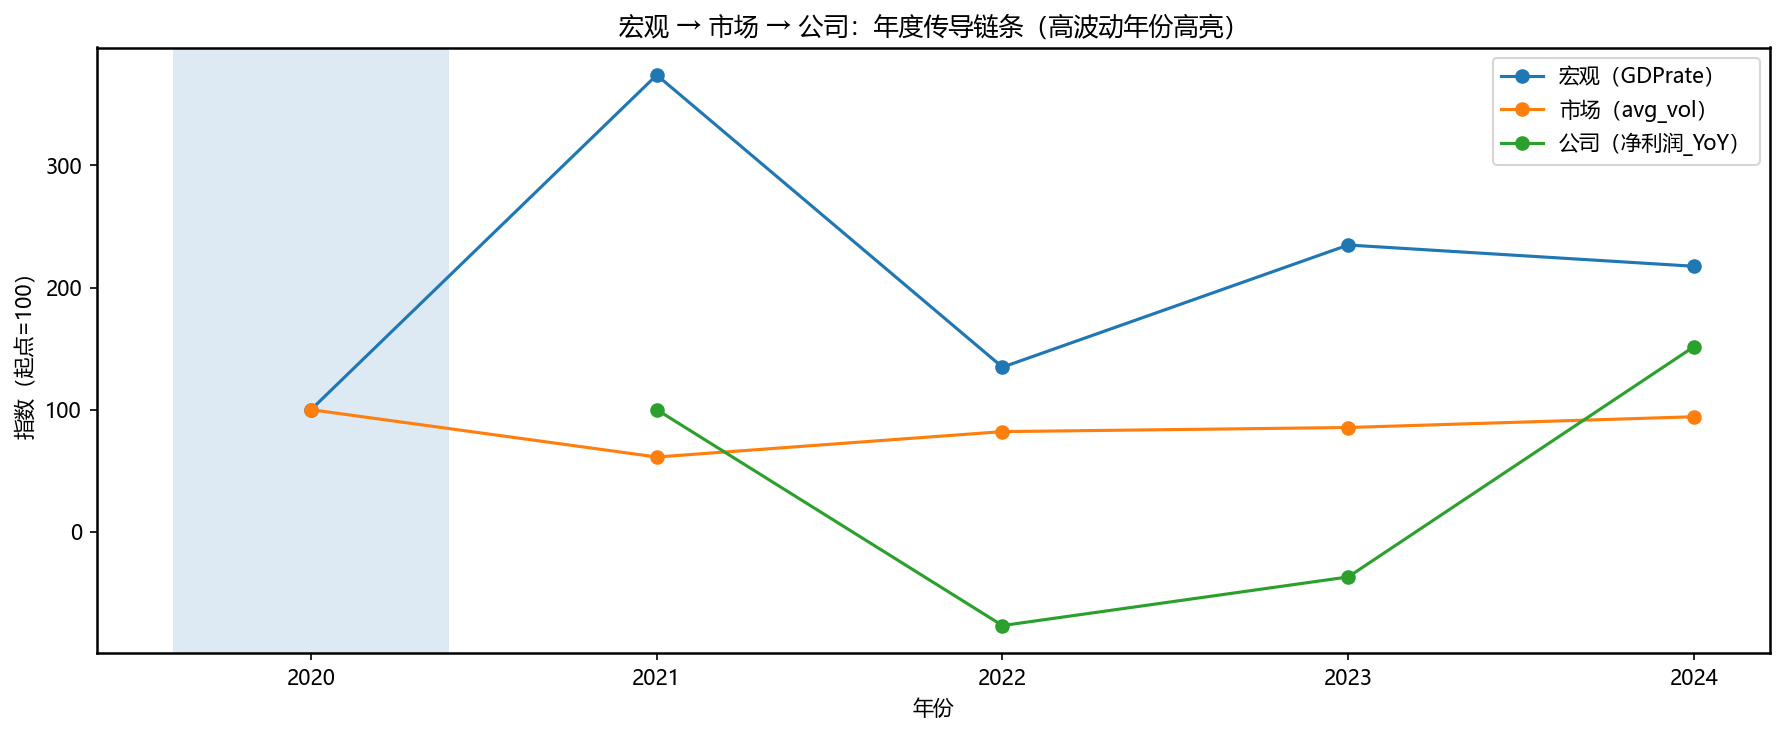

In [28]:
df = final_panel.copy().sort_values("year")

macro_col = "GDPrate" if "GDPrate" in df.columns else ("GDP_yoy" if "GDP_yoy" in df.columns else None)

market_col = "avg_vol" if "avg_vol" in df.columns else ("high_vol_ratio" if "high_vol_ratio" in df.columns else None)

company_col = None
for c in ["净利润_YoY", "营业总收入_YoY", "净利率_YoY"]:
    if c in df.columns:
        company_col = c
        break

print("宏观指标：", macro_col)
print("市场指标：", market_col)
print("公司指标：", company_col)

if (macro_col is None) or (market_col is None) or (company_col is None):
    raise ValueError("你的 final_panel 里缺少必要列。请把 df.columns 打印出来，我帮你对齐列名。")

def to_index100(s):
    s = s.astype(float)
    first = s.dropna().iloc[0]
    return (s / first) * 100

plot_df = df[["year", macro_col, market_col, company_col]].copy()
plot_df["宏观指数"] = to_index100(plot_df[macro_col])
plot_df["市场指数"] = to_index100(plot_df[market_col])
plot_df["公司指数"] = to_index100(plot_df[company_col])

high_years = []
if "high_vol_ratio" in df.columns:
    high_year = int(df.sort_values("high_vol_ratio", ascending=False).iloc[0]["year"])
    high_years = [high_year]
    print("识别出的高波动年份：", high_years)

plt.figure(figsize=(12, 5))

plt.plot(plot_df["year"], plot_df["宏观指数"], marker="o")
plt.plot(plot_df["year"], plot_df["市场指数"], marker="o")
plt.plot(plot_df["year"], plot_df["公司指数"], marker="o")

for y in high_years:
    plt.axvspan(y - 0.4, y + 0.4, alpha=0.15)

plt.xlabel("年份")
plt.ylabel("指数（起点=100）")
plt.title("宏观 → 市场 → 公司：年度传导链条（高波动年份高亮）")
plt.legend([f"宏观（{macro_col}）", f"市场（{market_col}）", f"公司（{company_col}）"])

plt.tight_layout()
plt.show()

### 3.分析

（1）宏观（GDP）：主导趋势但传导存在滞后  
2021年宏观指数（GDP增速）冲高，对应疫情后经济复苏；2022年回落（经济增速放缓），2023-2024年企稳回升。宏观波动未直接冲击市场，也未立刻传导至公司利润，体现宏观到微观的传导存在时滞。

（2）市场（平均波动率）：始终保持平稳，是 “缓冲层”  
2020-2024年市场平均波动率（橙线）基本维持在100左右，未随宏观波动而剧烈变化，说明市场整体情绪稳定，未放大宏观或公司层面的波动，对宏观→公司的传导起到了缓冲作用。

（3）公司（净利润同比）：受自身财务+宏观滞后影响  
2021-2022年：宏观冲高后回落，公司净利润同比（绿线）从正转负，对应财务数据中2022年净利润仅微增、经营现金流为负（盈利“账面化”），体现宏观放缓+自身财务压力的双重影响；2023-2024年：宏观企稳回升，公司净利润同比从负大幅修复，对应财务数据中2024年经营现金流高增（经营造血能力增强），体现宏观回暖+自身现金流优化的共振。

核心结论  
三者的传导逻辑是：宏观主导趋势→市场平稳缓冲→公司利润受自身财务+宏观滞后影响，卓易信息的业绩波动更多是“自身财务（负债、现金流）+宏观滞后传导”共同作用的结果，市场未放大波动。



## 五.文本分析

### 1.将年报转化为txt并进行清洗

代码如下：

In [29]:
report_dir = "annual_reports"

pdf_files = sorted([
    os.path.join(report_dir, f)
    for f in os.listdir(report_dir)
    if f.lower().endswith(".pdf")
])

print("识别到的年报文件：")
for f in pdf_files:
    print(f)

识别到的年报文件：
annual_reports\688258.2020.pdf
annual_reports\688258.2021.pdf
annual_reports\688258.2022.pdf
annual_reports\688258.2023.pdf
annual_reports\688258.2024.pdf


In [30]:
for pdf_path in pdf_files:
    with pdfplumber.open(pdf_path) as pdf:
        print(f"{os.path.basename(pdf_path)} | 页数：{len(pdf.pages)}")


688258.2020.pdf | 页数：194
688258.2021.pdf | 页数：208
688258.2022.pdf | 页数：233
688258.2023.pdf | 页数：280
688258.2024.pdf | 页数：272


In [31]:
pdf_path = pdf_files[0]

texts = []

with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        text = page.extract_text()
        if text:
            text = re.sub(r"\s+", " ", text)
            texts.append(text)

full_text = "\n".join(texts)

print("字符数：", len(full_text))
print("前300字预览：\n", full_text[:300])

字符数： 165610
前300字预览：
 2020年年度报告 公司代码：688258 公司简称：卓易信息 江苏卓易信息科技股份有限公司 2020 年年度报告 1 / 194
2020年年度报告 重要提示 一、 本公司董事会、监事会及董事、监事、高级管理人员保证年度报告内容的真实、准确、完整， 不存在虚假记载、误导性陈述或重大遗漏，并承担个别和连带的法律责任。 二、 重大风险提示 公司已在本报告中详细阐述公司在经营过程中可能面临的各种风险及应对措施，敬请查阅本 报告第四节“经营情况讨论与分析” 三、 公司全体董事出席董事会会议。 四、 天衡会计师事务所（特殊普通合伙）为本公司出具了标准无保留意见的审计报告。 五、 公司负责人谢乾、主管会


In [32]:
all_reports_text = {}

for pdf_path in pdf_files:
    year = os.path.basename(pdf_path).replace(".pdf", "")
    texts = []

    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            if text:
                text = re.sub(r"\s+", " ", text)
                texts.append(text)

    full_text = "\n".join(texts)
    all_reports_text[year] = full_text

    print(year, "字符数：", len(full_text))

688258.2020 字符数： 165610
688258.2021 字符数： 168487
688258.2022 字符数： 188896
688258.2023 字符数： 204880
688258.2024 字符数： 213486


In [33]:
out_dir = "annual_reports/data/txt"
os.makedirs(out_dir, exist_ok=True)

stats = []

for pdf_path in pdf_files:
    file_name = os.path.basename(pdf_path)

    m = re.search(r"(20\d{2})", file_name)
    year = m.group(1) if m else file_name.replace(".pdf", "")

    texts = []
    total_pages = 0
    empty_pages = 0

    with pdfplumber.open(pdf_path) as pdf:
        total_pages = len(pdf.pages)

        for page in pdf.pages:
            text = page.extract_text()
            if text and text.strip():
                text = re.sub(r"\s+", " ", text)
                texts.append(text)
            else:
                empty_pages += 1

    full_text = "\n".join(texts)

    txt_path = os.path.join(out_dir, f"{year}.txt")
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(full_text)

    word_count = len(full_text)
    success_rate = (total_pages - empty_pages) / total_pages if total_pages > 0 else 0
    empty_ratio = empty_pages / total_pages if total_pages > 0 else 0

    stats.append([year, total_pages, empty_pages, round(empty_ratio, 4), round(success_rate, 4), word_count])

    print(f"✅ {year} 年报已保存：{txt_path} | 字符数={word_count} | 空页比例={empty_ratio:.2%}")

print("\n===== PDF→TXT 汇总报告 =====")
print("year | 总页数 | 空页数 | 空页比例 | 提取成功率 | 字符数")
for row in stats:
    print(row)

✅ 2020 年报已保存：annual_reports/data/txt\2020.txt | 字符数=165610 | 空页比例=0.00%
✅ 2021 年报已保存：annual_reports/data/txt\2021.txt | 字符数=168487 | 空页比例=0.00%
✅ 2022 年报已保存：annual_reports/data/txt\2022.txt | 字符数=188896 | 空页比例=0.00%
✅ 2023 年报已保存：annual_reports/data/txt\2023.txt | 字符数=204880 | 空页比例=0.00%
✅ 2024 年报已保存：annual_reports/data/txt\2024.txt | 字符数=213486 | 空页比例=0.00%

===== PDF→TXT 汇总报告 =====
year | 总页数 | 空页数 | 空页比例 | 提取成功率 | 字符数
['2020', 194, 0, 0.0, 1.0, 165610]
['2021', 208, 0, 0.0, 1.0, 168487]
['2022', 233, 0, 0.0, 1.0, 188896]
['2023', 280, 0, 0.0, 1.0, 204880]
['2024', 272, 0, 0.0, 1.0, 213486]


In [34]:
txt_dir = "annual_reports/data/txt"
stop_path = "annual_reports/data/stopwords.txt"

with open(stop_path, "r", encoding="utf-8") as f:
    stopwords = set([line.strip() for line in f if line.strip()])

txt_files = sorted([os.path.join(txt_dir, f) for f in os.listdir(txt_dir) if f.endswith(".txt")])
print("识别到的TXT：", [os.path.basename(x) for x in txt_files])

def tokenize(text):
    """中文分词 + 基础清洗（零基础友好版）"""
    text = re.sub(r"[a-zA-Z0-9]+", " ", text)
    text = re.sub(r"[^\u4e00-\u9fa5]+", " ", text)
    words = jieba.lcut(text)
    words = [w for w in words if (len(w) >= 2) and (w not in stopwords)]
    return words

year_top = {}
all_words = []

for path in txt_files:
    year = os.path.basename(path).replace(".txt", "")
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()

    words = tokenize(text)
    all_words.extend(words)

    top30 = Counter(words).most_common(30)
    year_top[year] = top30

    print(f"\n===== {year} Top30 高频词 =====")
    for w, c in top30:
        print(w, c)

print("\n===== 五年合并 Top30 高频词 =====")
top30_all = Counter(all_words).most_common(30)
for w, c in top30_all:
    print(w, c)

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\chenx\AppData\Local\Temp\jieba.cache


识别到的TXT： ['2020.txt', '2021.txt', '2022.txt', '2023.txt', '2024.txt']


Loading model cost 1.160 seconds.
Prefix dict has been built successfully.



===== 2020 Top30 高频词 =====
资产 330
投资 311
项目 245
负债 213
价值 207
收益 195
服务 189
确认 187
企业 178
变动 161
收入 156
现金 156
损失 149
公允 144
损益 143
客户 137
业务 136
固件 136
经营 132
计算 130
技术 129
权益 126
合同 122
计量 122
信息 120
股东 119
本人 119
计入 118
交易 118
成本 117

===== 2021 Top30 高频词 =====
资产 348
投资 284
项目 220
价值 219
收益 191
负债 190
确认 182
变动 181
租赁 172
服务 170
企业 163
现金 159
损失 157
客户 153
损益 150
经营 144
公允 143
计量 140
发展 134
业务 134
成本 134
收入 132
股东 131
权益 129
计算 129
信息 122
计入 121
合同 120
合并 116
支付 111

===== 2022 Top30 高频词 =====
资产 355
投资 319
价值 240
项目 239
收益 206
确认 198
服务 192
负债 192
变动 191
企业 189
发展 179
现金 167
公允 162
损益 158
租赁 158
信息 157
损失 156
经营 147
业务 147
客户 146
成本 143
计量 141
收入 140
权益 129
股东 129
计入 127
计算 126
资金 126
卓易 124
交易 123

===== 2023 Top30 高频词 =====
资产 377
投资 311
价值 260
项目 220
企业 206
确认 206
现金 202
变动 201
服务 194
负债 188
业务 180
信息 178
收益 177
公允 175
坏账 166
收入 164
计提 163
合并 157
经营 156
股权 156
产品 156
损益 156
损失 154
股东 152
客户 147
发展 146
技术 143
账面 143
软件 141
计算 140

===== 2024 Top30 高频词 =====
信息 436
卓易 384
资产 358

### 2.生成年报词云图

代码如下：

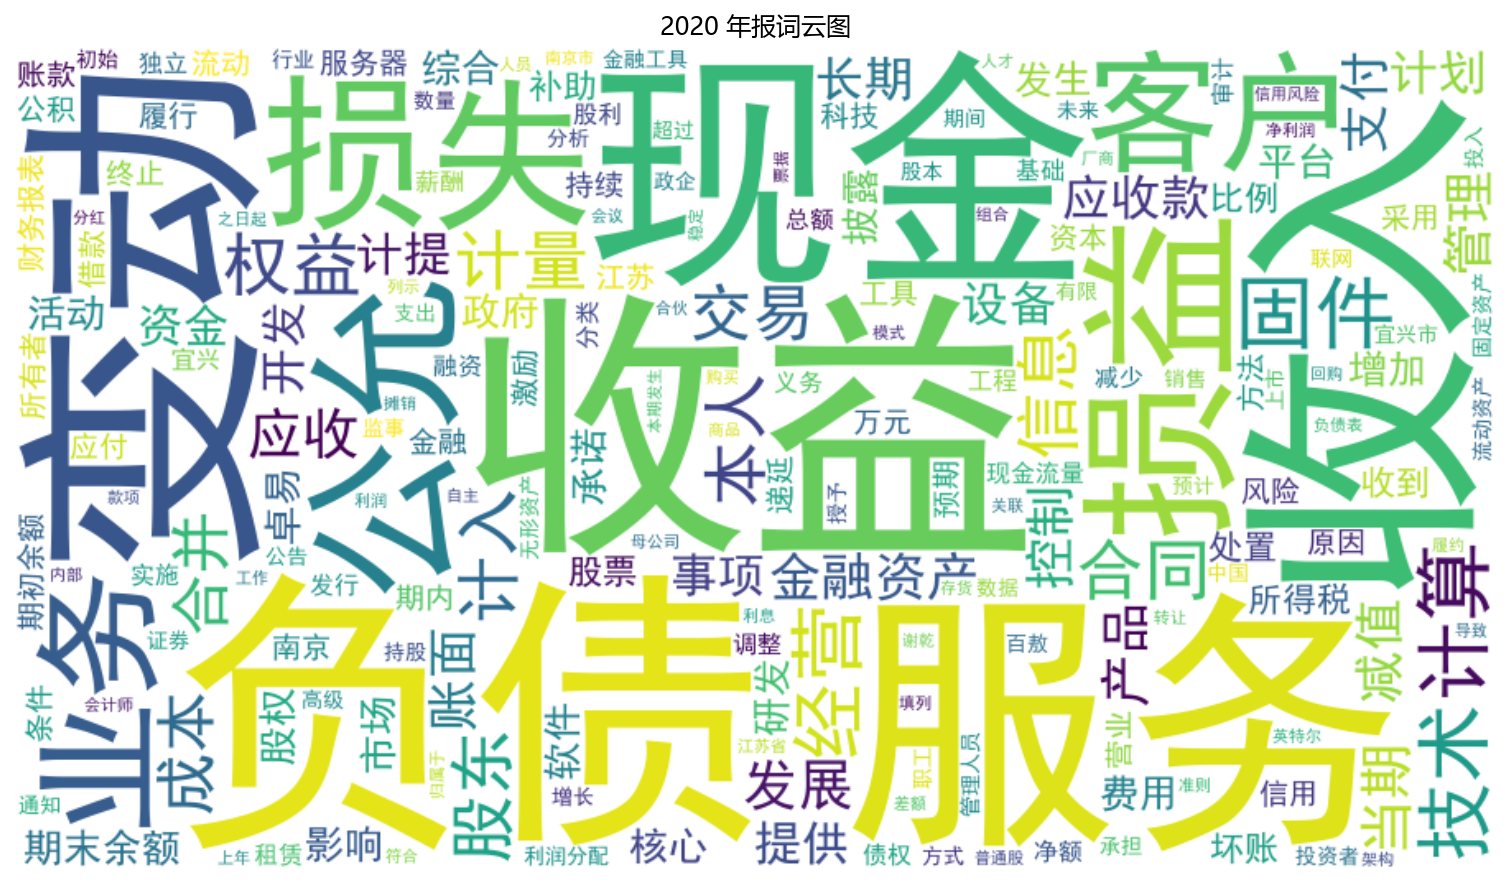

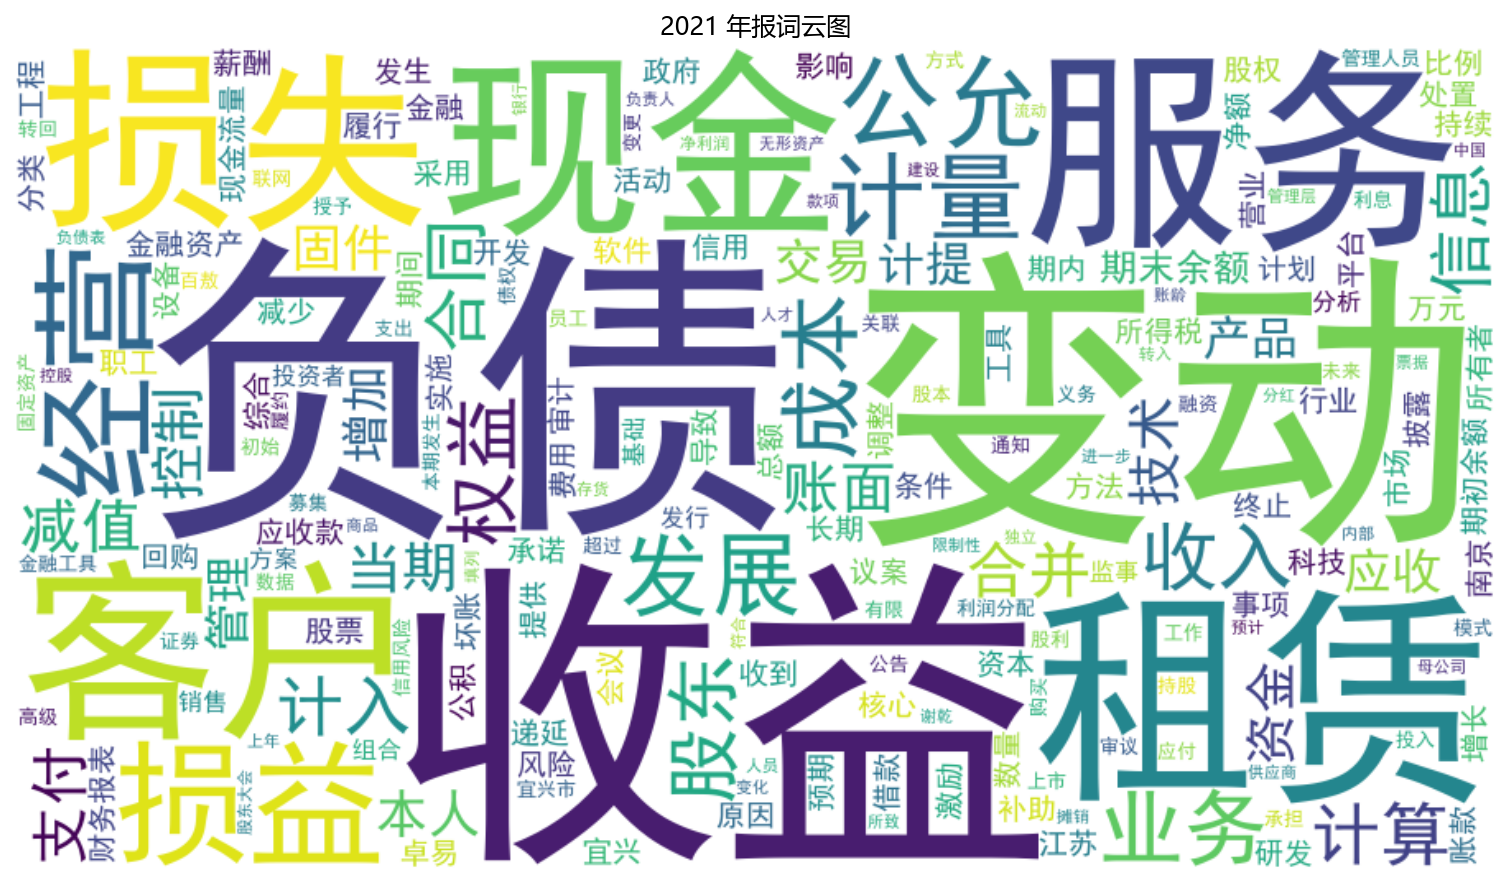

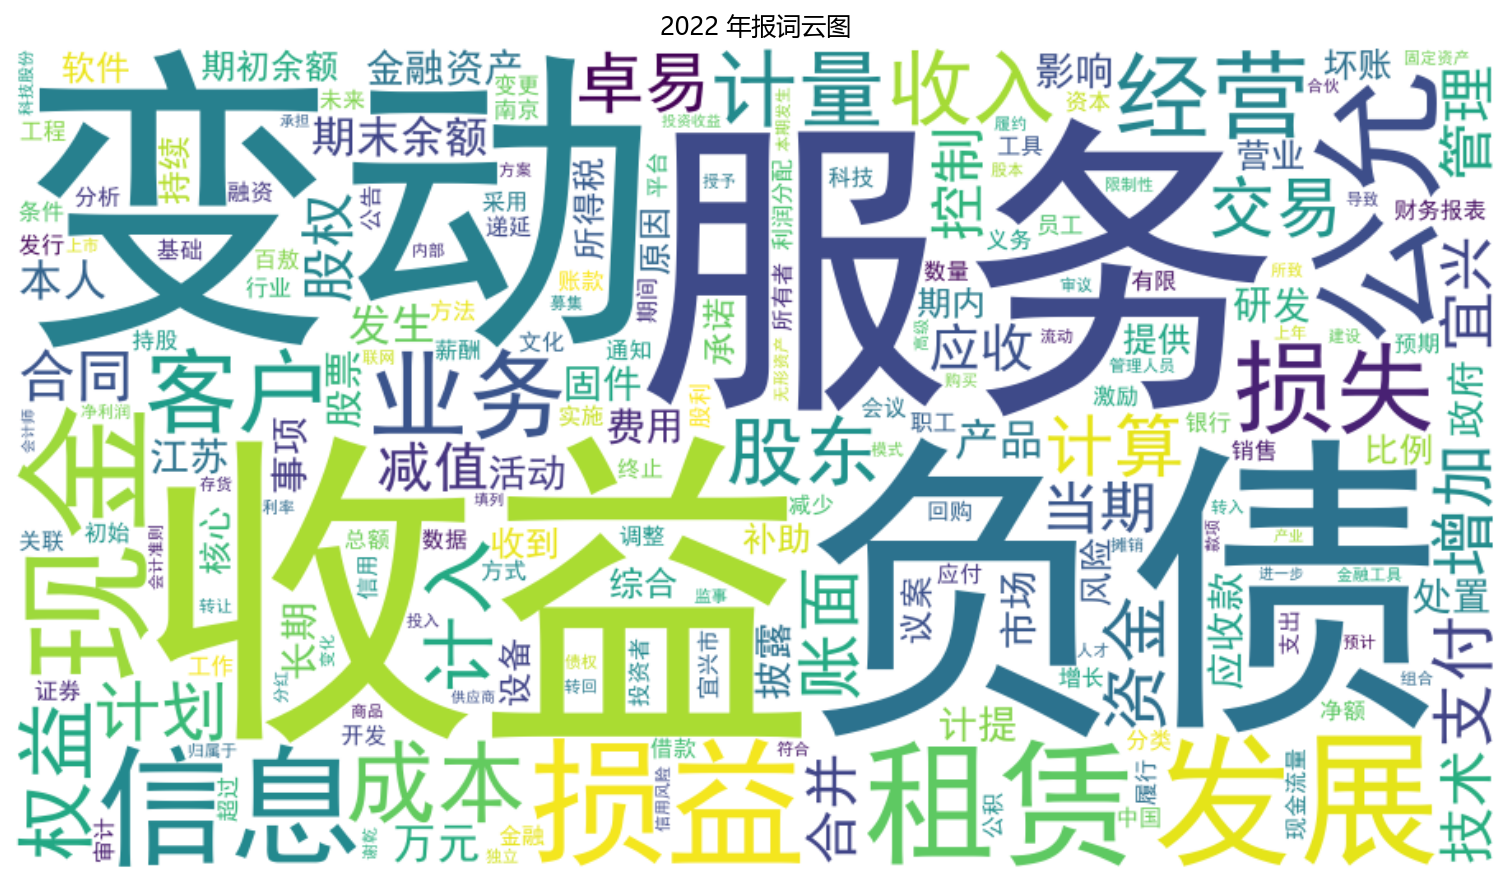

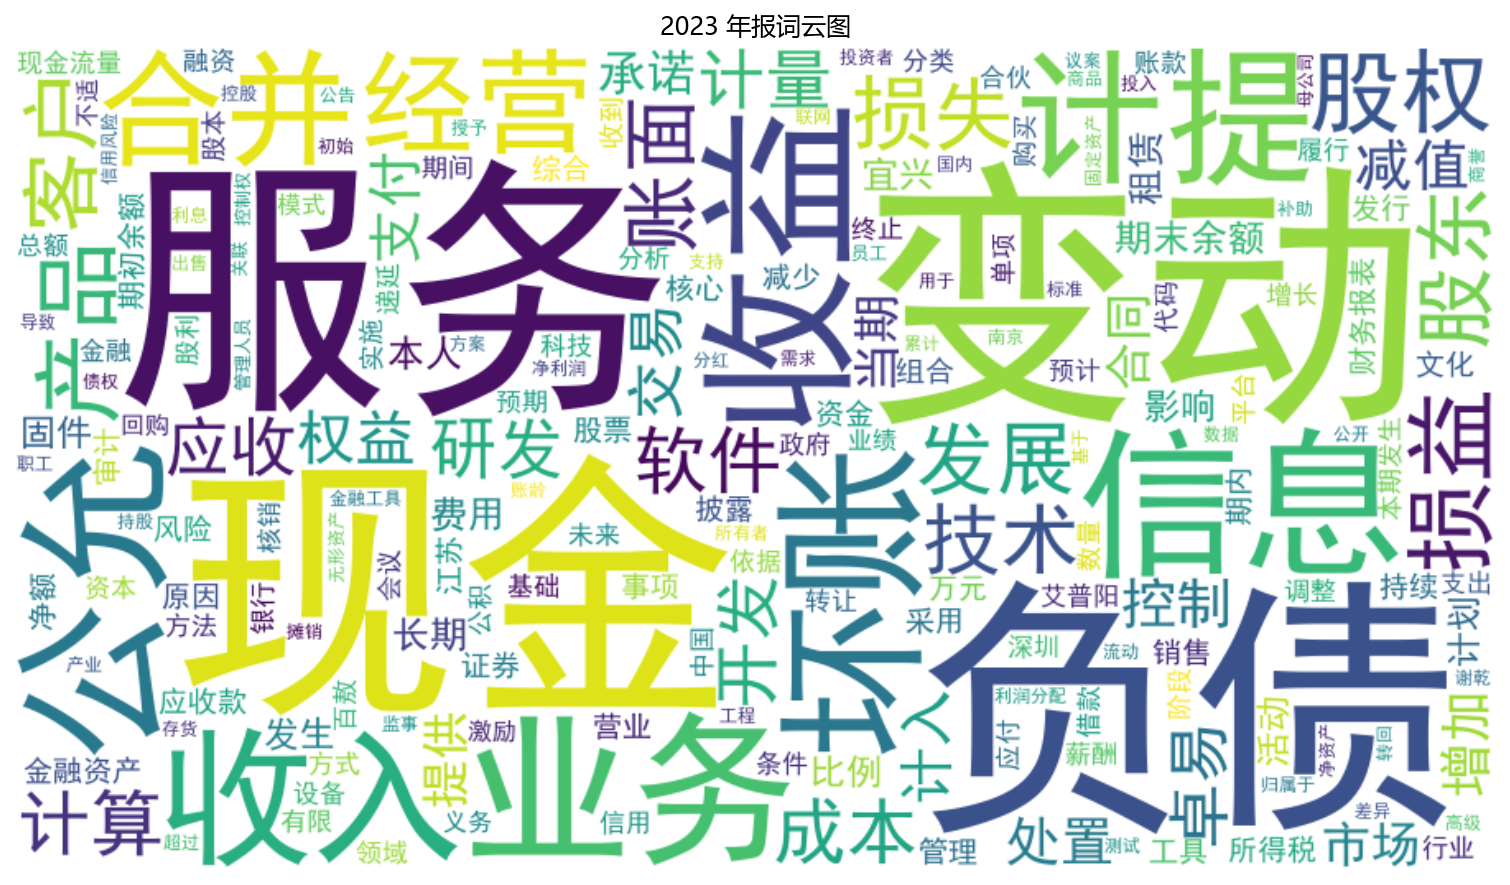

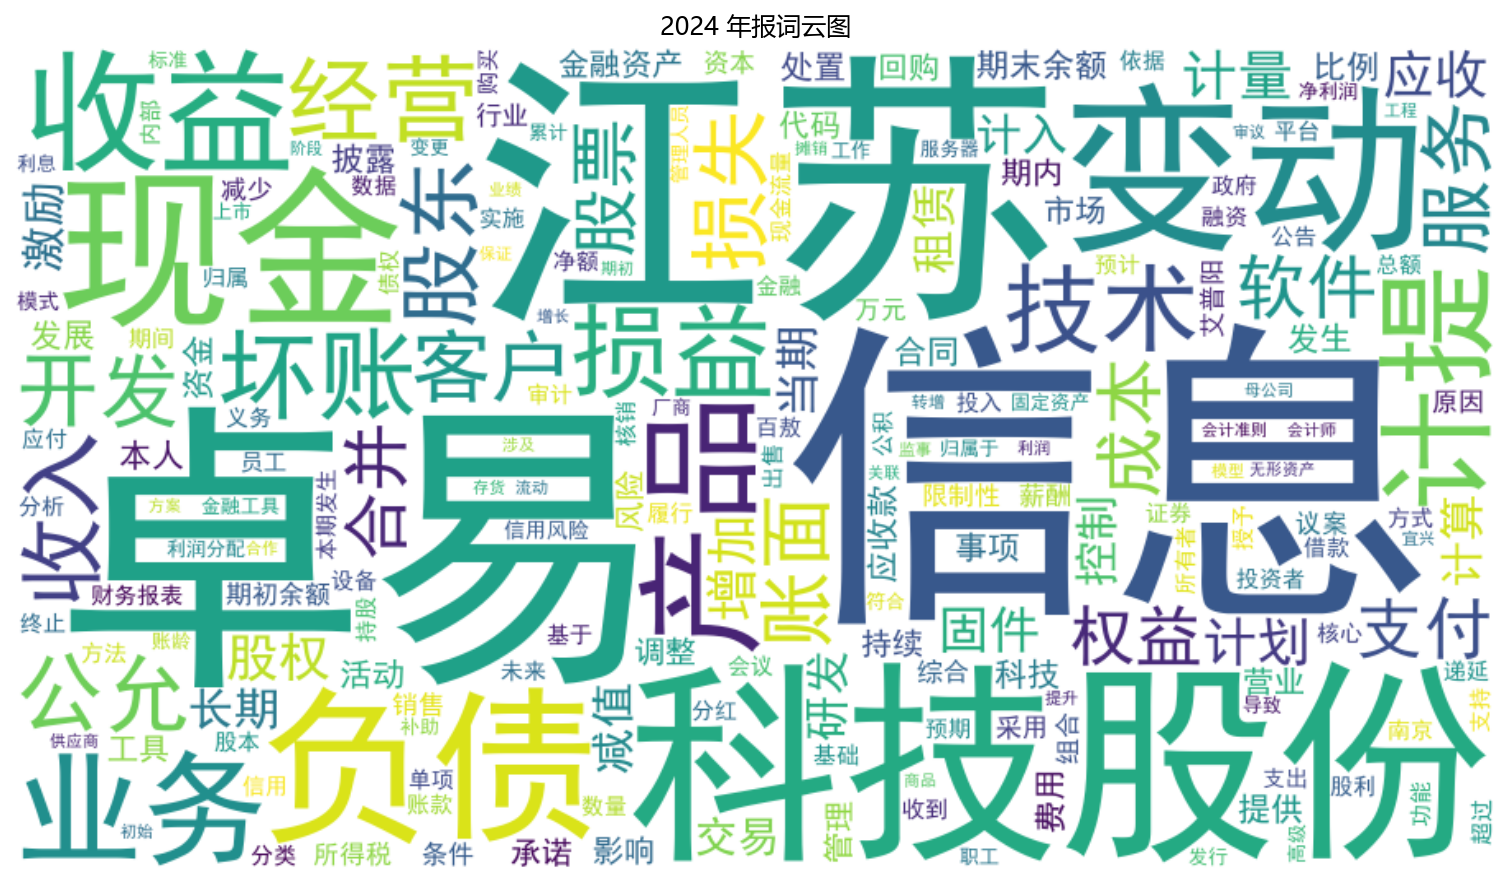

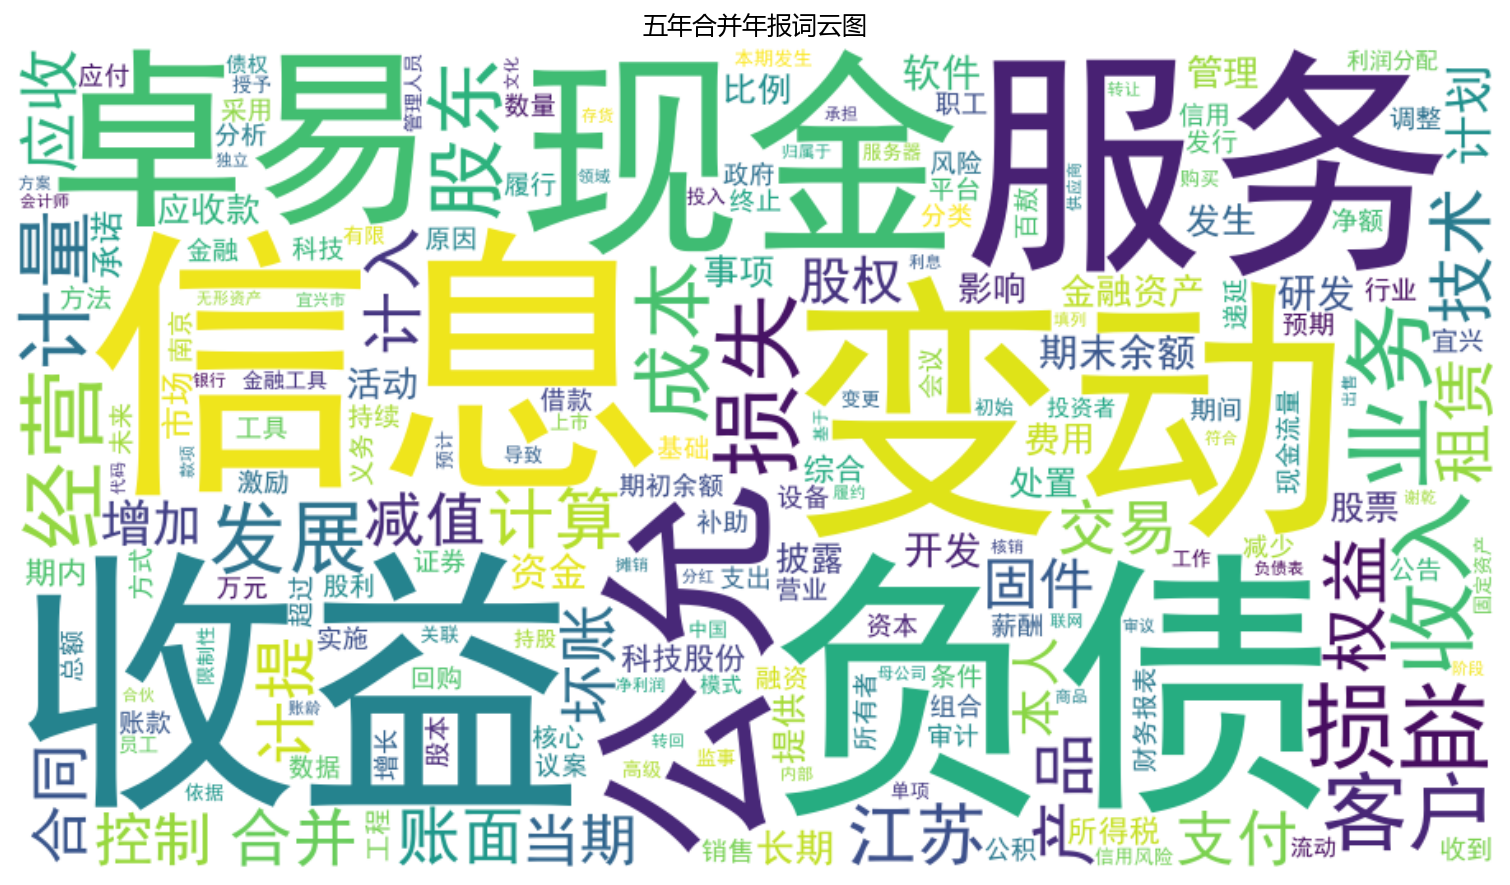

In [38]:
fig_dir = "annual_reports/data/fig"
os.makedirs(fig_dir, exist_ok=True)

with open("annual_reports/data/stopwords.txt", "r", encoding="utf-8") as f:
    stopwords = set([line.strip() for line in f if line.strip()])

def tokenize(text):
    text = re.sub(r"[a-zA-Z0-9]+", " ", text)
    text = re.sub(r"[^\u4e00-\u9fa5]+", " ", text)
    words = jieba.lcut(text)
    return [w for w in words if len(w) >= 2 and w not in stopwords]

def make_wordcloud(words, title, save_path):
    freqs = dict(Counter(words))

    wc = WordCloud(
        font_path="C:/Windows/Fonts/simhei.ttf",
        width=900,
        height=500,
        background_color="white"
    ).generate_from_frequencies(freqs)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.show()

txt_dir = "annual_reports/data/txt"
txt_files = sorted([f for f in os.listdir(txt_dir) if f.endswith(".txt")])

all_words = []

for fname in txt_files:
    year = fname.replace(".txt", "")
    with open(os.path.join(txt_dir, fname), "r", encoding="utf-8") as f:
        text = f.read()

    words = tokenize(text)
    all_words.extend(words)

    save_path = os.path.join(fig_dir, f"wordcloud_{year}.png")
    make_wordcloud(words, f"{year} 年报词云图", save_path)

make_wordcloud(
    all_words,
    "五年合并年报词云图",
    os.path.join(fig_dir, "wordcloud_all_5y.png")
)

### 3.年报词云图分析：

词云图直观呈现了卓易信息2020-2024年的业务核心与经营重点，结合其年报信息可从以下维度分析：

（1）核心业务聚焦：技术+服务双主线  
词云中“固件”“软件”“服务”“科技” 等大字号关键词，对应其核心业务——云计算设备核心固件（BIOS、BMC）+集成化开发工具（IDE）+云服务。固件是其“根技术”（国内少数掌握多架构BIOS的厂商），服务于Intel、华为等硬件厂商；IDE（如 PowerBuilder、SnapDevelop）面向政企/软件企业，2024年推出的低代码+AI编程工具是业务新增长点；“服务器”“平台”“金融工具” 等词则体现其云服务在政企、金融领域的布局。

（2）经营活动：财务与资本动作频繁
词云中“现金”“资产”“股权”“融资”“利润分配”等高频词，反映这五年的经营特点：  
现金流管理：经营活动现金流净额波动较大（2022年为负、2023年达1.14亿），“现金流量”“净额”等词是财务分析重点；  
资本运作：“股权”“转让”“发行”对应其股权调整、融资行为（如2024年收购艾普阳科技剩余股权）；  
财务合规：“应收账款”“应付”“合并”“审计”等词体现年报中对财务规范、合并报表的披露要求。

（3）发展驱动：研发与国产替代  
“研发”“投入”“独立”“国产”等词，契合其“自主可控”的战略方向：研发投入持续增加（2025年上半年研发费用增19.41%），对应 “科技”“技术”等关键词；“独立”“国产”“替代”体现其在信创背景下，固件、IDE产品对国外技术的替代属性（如BIOS替代国际厂商）。

（4）风险与管理：合规与运营细节  
“风险”“信用”“调整”“履行”等词，反映经营中的关注重点：金融类词汇（“金融资产”“债权”“信用”）对应其对客户信用、金融工具的管理；“调整”“终止”“事项”则涉及业务调整、合同履行等运营风险披露（如部分项目的终止或变更）。

总结  
这五年卓易信息的年报核心逻辑是：以固件技术为根基，通过IDE+云服务拓展业务边界，同时在资本、研发、合规层面持续投入，契合国产化替代与AI技术的行业趋势。词云中的高频词既体现了其业务的“技术属性”，也反映了经营中的“财务与合规属性”。

### 4.从年报中提取MD&A文本

代码如下：

In [47]:
import re
from pathlib import Path
import os

import fitz

TXT_DIR = Path("annual_reports/data/txt")
OUT_DIR = Path("annual_reports/data/mdna_full_3")
PDF_DIR = Path(".")
PDF_NAME_TMPL = "卓易信息{year}.pdf"

YEARS = [2020, 2021, 2022, 2023, 2024]

MIN_VALID_LEN = 20000

def normalize_keep_lines(text: str) -> str:
    text = text.replace("\u3000", " ")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{2,}", "\n", text)
    return text.strip()

def best_start_by_signals_in_txt(full_text: str, start_pat: str) -> int:
    cands = [m.start() for m in re.finditer(start_pat, full_text)]
    if not cands:
        return -1

    signals = [
        "经营情况讨论与分析", "报告期内", "主营业务", "收入", "同比", "毛利率",
        "云计算", "软件","产能利用率", "风险因素", "核心竞争力", "研发投入"
    ]

    best_i, best_score = cands[0], -10
    for i in cands:
        window = full_text[i:i + 2500]
        score = sum(1 for s in signals if s in window)

        near = full_text[max(0, i - 80): i + 80]
        if "请参阅" in near or "详见" in near:
            score -= 2

        if "第六节 公司治理" in window[:900] or "公司治理" in window[:900]:
            score -= 4

        if score > best_score:
            best_score = score
            best_i = i

    return best_i


def extract_mdna_from_txt(full_text: str, year: int) -> str:
    full_text = normalize_keep_lines(full_text)

    start_pat_2020 = r"第\s*五\s*节\s*经\s*营\s*情\s*况\s*讨\s*论\s*与\s*分\s*析"
    start_pat_4 = r"第\s*四\s*节\s*管\s*理\s*层\s*讨\s*论\s*(与|及|和)\s*分\s*析"
    fallback = r"报\s*告\s*期\s*内\s*主\s*要\s*经\s*营\s*情\s*况"

    if year == 2020:
        start_idx = best_start_by_signals_in_txt(full_text, start_pat_2020)
    else:
        start_idx = best_start_by_signals_in_txt(full_text, start_pat_4)

    if start_idx == -1:
        m = re.search(fallback, full_text)
        start_idx = m.start() if m else -1

    if start_idx == -1:
        return ""

    mdna = full_text[start_idx:start_idx + 300000]

    end_pats = [
        r"第\s*五\s*节\s*董\s*事\s*会\s*报\s*告",
        r"第\s*5\s*节\s*董\s*事\s*会\s*报\s*告",
        r"第\s*六\s*节",
        r"第\s*6\s*节",
    ]
    cut = None
    for ep in end_pats:
        m = re.search(ep, mdna[200:])
        if m:
            cut = 200 + m.start()
            break
    if cut:
        mdna = mdna[:cut]

    return mdna.strip()

def best_start_by_signals_in_pdf(full_text: str, start_key: str) -> int:
    cands = [m.start() for m in re.finditer(re.escape(start_key), full_text)]
    if not cands:
        return -1

    signals = ["经营情况讨论与分析", "报告期内", "主营业务", "云计算", "软件","收入", "同比", "风险因素"]
    best_i, best_score = cands[0], -10

    for i in cands:
        window = full_text[i:i + 2000]
        score = sum(1 for s in signals if s in window)

        if "目录" in full_text[max(0, i - 500): i + 120]:
            score -= 2

        if "第六节 公司治理" in window[:900] or "公司治理" in window[:900]:
            score -= 4

        if score > best_score:
            best_score = score
            best_i = i

    return best_i


def extract_mdna_from_pdf(pdf_path: Path, year: int) -> str:
    doc = fitz.open(str(pdf_path))
    pages = [(doc.load_page(i).get_text("text") or "") for i in range(doc.page_count)]
    full_text = normalize_keep_lines("\n".join(pages))

    if year == 2020:
        s = best_start_by_signals_in_pdf(full_text, "第五节 经营情况讨论与分析")
        if s == -1:
            s = best_start_by_signals_in_pdf(full_text, "经营情况讨论与分析")
    else:
        s = best_start_by_signals_in_pdf(full_text, "第四节 管理层讨论与分析")
        if s == -1:
            s = best_start_by_signals_in_pdf(full_text, "管理层讨论与分析")

    if s == -1:
        return ""

    e = full_text.find("第五节 董事会报告", s + 50)
    if e == -1:
        e = full_text.find("董事会报告", s + 50)
    if e == -1:
        e2 = full_text.find("第六节", s + 50)
        if e2 != -1:
            e = e2

    mdna = full_text[s:] if e == -1 else full_text[s:e]
    return mdna.strip()

OUT_DIR.mkdir(parents=True, exist_ok=True)

for year in YEARS:
    txt_path = TXT_DIR / f"{year}.txt"
    pdf_path = PDF_DIR / PDF_NAME_TMPL.format(year=year)
    out_path = OUT_DIR / f"{year}_mdna_full_3.txt"

    mdna = ""
    used = "NONE"

    if txt_path.exists():
        mdna = extract_mdna_from_txt(txt_path.read_text(encoding="utf-8"), year)
        used = "TXT"

    if (len(mdna) < MIN_VALID_LEN) and pdf_path.exists():
        mdna_pdf = extract_mdna_from_pdf(pdf_path, year)
        if len(mdna_pdf) > len(mdna):
            mdna = mdna_pdf
            used = "PDF"

    out_path.write_text(mdna, encoding="utf-8")

    print(f"\n{year} -> {used} | 字符数: {len(mdna)} | 输出: {out_path}")
    print("前200字预览：", (mdna[:200].replace("\n", " ") if mdna else ""))
    if used == "TXT" and len(mdna) < MIN_VALID_LEN:
        print(f"⚠️ TXT提取过短（<{MIN_VALID_LEN}），但未找到PDF或PDF也失败；请检查 {pdf_path} 是否存在。")


2020 -> TXT | 字符数: 29026 | 输出: annual_reports\data\mdna_full_3\2020_mdna_full_3.txt
前200字预览： 报告期内主要经营情况 报告期内，公司实现营业收入19,841.63万元，较2019年下降6.77%；归属于上市公司股 东的净利润5,805.33万元，较2019年增长41.34%。 (一)主营业务分析 1. 利润表及现金流量表相关科目变动分析表 单位:元 币种:人民币 科目 本期数 上年同期数 变动比例（%） 营业收入 198,416,265.14 212,833,556.40 -6.77 营业成

2021 -> TXT | 字符数: 26997 | 输出: annual_reports\data\mdna_full_3\2021_mdna_full_3.txt
前200字预览： 报告期内主要经营情况 具体详见本节“一、经营情况讨论与分析” (一) 主营业务分析 1. 利润表及现金流量表相关科目变动分析表 单位：元 币种：人民币 科目 本期数 上年同期数 变动比例（%） 营业收入 236,604,121.94 198,416,265.14 19.25 营业成本 111,628,071.68 81,883,213.42 36.33 销售费用 5,264,212.81 5,07

2022 -> TXT | 字符数: 31028 | 输出: annual_reports\data\mdna_full_3\2022_mdna_full_3.txt
前200字预览： 报告期内主要经营情况 具体详见本节“一、经营情况讨论与分析” (一) 主营业务分析 1. 利润表及现金流量表相关科目变动分析表 单位：元 币种：人民币 科目 本期数 上年同期数 变动比例（%） 营业收入 282,022,751.67 236,604,121.94 19.20 营业成本 137,884,025.08 111,628,071.68 23.52 销售费用 9,955,637.65 5,2

2023 -> TXT | 字符数: 31638 | 输出: annual_reports\data\mdna_full_3\2023_mdna_full_3.txt
前200字预览： 报告期内主要经营情况 具体详见本节“一、经

In [48]:
sentiment_dir = "annual_reports/data"

with open(os.path.join(sentiment_dir, "positive.txt"), "r", encoding="gbk") as f:
    positive_words = set(line.strip() for line in f if line.strip())

with open(os.path.join(sentiment_dir, "negative.txt"), "r", encoding="gbk") as f:
    negative_words = set(line.strip() for line in f if line.strip())

print("正向词数量：", len(positive_words))
print("负向词数量：", len(negative_words))

print("正向词示例：", list(positive_words)[:10])
print("负向词示例：", list(negative_words)[:10])

正向词数量： 268
负向词数量： 190
正向词示例： ['继续加强', '顺利完成', '凝聚力', '完善', '逐步提高', '高质量', '新高', '强劲', '前所未有', '共赢']
负向词示例： ['困扰', '下滑', '老旧', '改进', '最低', '竞争', '停产', '持平', '下降', '终止']


In [49]:
from pathlib import Path
import re

import jieba
import pandas as pd

MDNA_DIR = Path("annual_reports/data/mdna_full_3")
FILE_GLOB = "*_mdna_full_3.txt"

positive_words = set(positive_words)
negative_words = set(negative_words)

mdna_texts = {}
files = sorted(MDNA_DIR.glob(FILE_GLOB))

if not files:
    raise FileNotFoundError(f"在 {MDNA_DIR.resolve()} 下未找到匹配文件：{FILE_GLOB}")

for p in files:
    m = re.search(r"(19|20)\d{2}", p.name)
    if not m:
        continue
    year = int(m.group())

    text = p.read_text(encoding="utf-8").strip()
    mdna_texts[year] = text

if not mdna_texts:
    raise ValueError("未能从文件名中解析出任何年份，请检查文件命名是否包含 4 位年份。")

print("已加载 MD&A 年份：", sorted(mdna_texts.keys()))

def sentiment_score(text, pos_words, neg_words):
    words = jieba.lcut(text)
    pos_cnt = sum(1 for w in words if w in pos_words)
    neg_cnt = sum(1 for w in words if w in neg_words)

    if pos_cnt + neg_cnt == 0:
        return 0, pos_cnt, neg_cnt

    score = (pos_cnt - neg_cnt) / (pos_cnt + neg_cnt)
    return score, pos_cnt, neg_cnt

rows = []

for year, text in mdna_texts.items():
    score, pos_cnt, neg_cnt = sentiment_score(text, positive_words, negative_words)
    rows.append([year, score, pos_cnt, neg_cnt, len(text)])

sentiment_df = (
    pd.DataFrame(rows, columns=["year", "sentiment", "pos_count", "neg_count", "mdna_length"])
    .sort_values("year")
    .reset_index(drop=True)
)

sentiment_df["pos_per_10k"] = sentiment_df["pos_count"] / sentiment_df["mdna_length"] * 10000
sentiment_df["neg_per_10k"] = sentiment_df["neg_count"] / sentiment_df["mdna_length"] * 10000
sentiment_df["neg_ratio"] = sentiment_df["neg_count"] / (sentiment_df["pos_count"] + sentiment_df["neg_count"]).replace(0, pd.NA)

print("\n年度 MD&A 情感结果：")
print(sentiment_df)

out_csv = MDNA_DIR / "mdna_sentiment_by_year.csv"
sentiment_df.to_csv(out_csv, index=False, encoding="utf-8-sig")
print("\n已保存：", out_csv)

已加载 MD&A 年份： [2020, 2021, 2022, 2023, 2024]

年度 MD&A 情感结果：
   year  sentiment  pos_count  neg_count  mdna_length  pos_per_10k  \
0  2020   0.266319        485        281        29026   167.091573   
1  2021   0.479542        452        159        26997   167.426010   
2  2022   0.471074        534        192        31028   172.102617   
3  2023   0.409836        516        216        31638   163.095012   
4  2024   0.295045        575        313        36689   156.722723   

   neg_per_10k  neg_ratio  
0    96.809757   0.366841  
1    58.895433   0.260229  
2    61.879593   0.264463  
3    68.272331   0.295082  
4    85.311674   0.352477  

已保存： annual_reports\data\mdna_full_3\mdna_sentiment_by_year.csv


### 5.情感分析

这是卓易信息2020-2024年MD&A（管理层讨论与分析）的情感分析数据，能直观反映年报中管理层的语气倾向和内容侧重。

（1）情感倾向（sentiment）  
2021-2022年情感值最高（0.47+）：这两年管理层语气更积极，可能对应业务扩张、业绩较好的阶段；2020、2024年情感值较低（0.26-0.29）：这两年负面表述占比回升，语气相对谨慎。

（2）正负表述数量
正面表述（pos_count）：2024年最多（575条），但负面表述（neg_count）也同步增至313条，说明内容更 “全面” 但争议点变多；负面表述：2020、2024年显著高于中间三年（281/313vs159-216），对应这两年风险、问题的披露更密集。

（3）密度与占比
负面占比（neg_ratio）：2020、2024年超过35%，2021-2022年低于27%——这两年管理层对风险的强调明显减少；内容长度（mdna_length）：逐年递增（2.9万→3.67万），说明年报披露的信息越来越详细。

总结趋势：
卓易信息的MD&A呈现“扩张期积极，调整期谨慎”的特点：2021-2022年业务顺境时，管理层语气更乐观、负面表述少；2020、2024年（可能是业务调整/外部环境波动期），负面表述占比回升，语气回归理性。

### 6.情感折线图

代码如下：

In [50]:
def calc_sentiment(text, pos_set, neg_set):
    words = jieba.lcut(text)

    pos_cnt = sum(1 for w in words if w in pos_set)
    neg_cnt = sum(1 for w in words if w in neg_set)

    if pos_cnt + neg_cnt == 0:
        score = 0
    else:
        score = (pos_cnt - neg_cnt) / (pos_cnt + neg_cnt)

    total = pos_cnt + neg_cnt
    pos_ratio = pos_cnt / total if total > 0 else 0
    neg_ratio = neg_cnt / total if total > 0 else 0

    return score, pos_cnt, neg_cnt, pos_ratio, neg_ratio

rows = []
for year, text in mdna_texts.items():
    score, pos_cnt, neg_cnt, pos_ratio, neg_ratio = calc_sentiment(
        text, positive_words, negative_words
    )
    rows.append([year, len(text), pos_cnt, neg_cnt, pos_ratio, neg_ratio, score])

sent_df = pd.DataFrame(rows, columns=[
    "year", "mdna_chars", "pos_cnt", "neg_cnt", "pos_ratio", "neg_ratio", "sentiment"
]).sort_values("year")

print(sent_df)

   year  mdna_chars  pos_cnt  neg_cnt  pos_ratio  neg_ratio  sentiment
0  2020       29026      485      281   0.633159   0.366841   0.266319
1  2021       26997      452      159   0.739771   0.260229   0.479542
2  2022       31028      534      192   0.735537   0.264463   0.471074
3  2023       31638      516      216   0.704918   0.295082   0.409836
4  2024       36689      575      313   0.647523   0.352477   0.295045


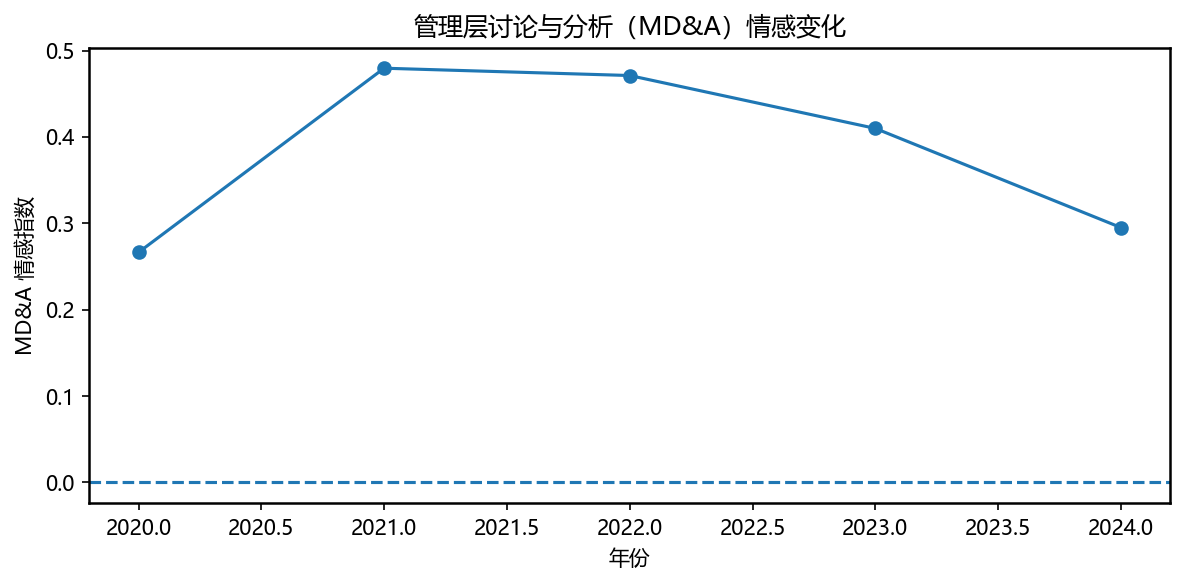

In [51]:
plt.figure(figsize=(8, 4))
plt.plot(sentiment_df["year"], sentiment_df["sentiment"], marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("年份")
plt.ylabel("MD&A 情感指数")
plt.title("管理层讨论与分析（MD&A）情感变化")
plt.tight_layout()
plt.show()

In [52]:
worst_year = sentiment_df.sort_values("sentiment").iloc[0]["year"]
print("情感最低年份：", worst_year)

text = mdna_texts[int(worst_year)]

sentences = re.split("。|；", text)
evidence = [s for s in sentences if ("风险" in s or "不确定" in s)]

print("\n文本证据示例（最多3条）：")
for s in evidence[:3]:
    print("-", s[:40])

情感最低年份： 2020.0

文本证据示例（最多3条）：
- BIOS、BMC固件作 为计算设备连接CPU和操作系统的桥梁，具备有效降低信息安
- 国产BIOS及BMC固件可以设置独立于硬件的安全认证机制，通过固件数字签名、安 
-  公司分别于2019年12月30日召开第三届董事会第四次会议、第三届监事会第三次


## 六.整体分析

### 1.从词云的核心关键词，能清晰对应其战略的三大支柱：

（1）核心技术锚点：自主可控的固件与科技能力  
词云中“固件、软件、技术、科技”的高权重，是其战略根基——聚焦BIOS/BMC等硬件固件的自主研发，打破国外技术垄断，契合信创背景下的 “国产替代” 主线；“独立、研发、方法”则体现其对技术自主性、研发持续性的重视。

（2）业务扩张逻辑：从“产品”到“产品+服务+解决方案”  
“服务、平台、客户、方案”的高频出现，对应战略从“单一固件产品”向“综合服务”延伸：面向硬件厂商提供固件产品；面向企业客户提供 IDE开发工具、云服务；覆盖金融、政企等行业的数字化解决方案。

（3）运营与资本支撑：以资产/现金流为基础的稳健扩张  
“现金、资产、股权、融资”等关键词，体现战略落地的保障：通过“股权、融资”获取扩张资金，投入“研发、投入”强化技术；以“现金、资产”管理为核心，保障业务扩张中的财务稳健。

（4）生态布局方向：绑定国产化产业链  
“国产、替代、宜兴、江苏” 等词，对应其战略的区域与产业链绑定：立足宜兴（公司注册地）、辐射江苏，深度参与区域信创项目；以“替代、独立”为标签，融入国产化硬件、软件的产业链生态。

### 2.总结

综合卓易信息2020-2024年股票、财务、宏观及MD&A情感分析多维度数据，核心投资逻辑为“国产替代稀缺性+AI技术赋能第二增长曲线”双重驱动，短期受益信创产业落地，长期依托技术壁垒与业务协同实现价值重估，同时需警惕业绩波动等相关风险，具体核心结论如下：

（1）核心投资价值
- 宏观与行业红利共振，公司作为国产基础固件稀缺标的，深度受益信创国产替代浪潮，市场增长空间明确。  
- 业务结构升级成效初显，AI+IDE业务成为第二增长曲线，长期成长潜力显著。  
- 财务基本面边际改善趋势明确，盈利能力稳步提升，为估值修复提供支撑。  

（2）风险提示
- 业绩波动风险：业务转型期短期压力尚存，IDE业务商业化进程及固件业务受行业周期影响，可能导致业绩波动。
- 行业竞争与技术风险：国内外竞争加剧及技术迭代速度快，若研发投入不足或路线误判，可能丧失竞争优势。
- 宏观与政策风险：信创产业政策推进节奏不及预期，可能影响核心业务订单释放与收入确认。

（3）投资结论  
卓易信息作为国产基础软件稀缺标的，核心业务受益确定性红利，第二增长曲线打开长期空间，业绩与财务基本面改善印证转型成效，长期投资价值凸显。短期关注核心业务进展，中长期看好其赛道稀缺性价值。